# Model Analysis: Uncertainty, Calibration & OOD Detection

This notebook provides a complete analysis pipeline for models trained with different logits targets:
1. **Model Configuration** - Specify model path and softmax/remax method
2. **Predictions & Metrics** - Generate predictions with total and epistemic uncertainty
3. **Data Quality** - Count out-of-bounds predictions (without filtering)
4. **Calibration** - ECE plot to assess model calibration
5. **High Uncertainty Analysis** - Visualize top 10 highest entropy and variance examples
6. **OOD Detection** - Entropy distributions for ID (CIFAR-10) vs OOD (SVHN)
7. **Rejection Curves** - Performance under selective prediction for both uncertainty types

## Setup and Imports

In [1]:
import os
import sys

# Add the 'build' directory to sys.path
sys.path.append(
    os.path.normpath(os.path.join(os.path.dirname(os.getcwd()), "build"))
)

import numpy as np
from scipy.stats import norm, gaussian_kde
import torch
import torchvision
import torchvision.transforms.v2 as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

import pytagi
from tagi_resnet_model import resnet18_cifar10
from calibration_utils import (
    remax_analytical, softmax_analytical, apply_remax,
    collect_logits, calculate_metrics, evaluate_with_params,
    load_calibration_params
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 5)

print(f"PyTAGI CUDA available: {pytagi.cuda.is_available()}")

/home/mf2/.miniconda3/envs/cuTAGI/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


PyTAGI CUDA available: True


## Configuration

**Modify these parameters to analyze different models:**

In [2]:
# ============================================================
# MODEL CONFIGURATION - MODIFY THESE FOR DIFFERENT MODELS
# ============================================================

# Path to your trained model checkpoint
CHECKPOINT_PATH = "../checkpoints/calibration_run/best_model_1_1.bin"

# Choose output transformation: 'softmax' or 'remax'
OUTPUT_METHOD = 'remax'  # Options: 'softmax', 'remax'

# Calibration parameters (scale and shift for logits)
SCALE = 10.3373
SHIFT = 9.4423

# Softmax
# 1.0060, Shift=6.9312
# SCALE = 1.0
# SHIFT = 0.0

# Remax
# Scale=7.3141, Shift=20.0000
# SCALE = 3.6491
# SHIFT = 10.0

# Scale=6.4740, Shift=-8.2197\
# SCALE = 6.4740
# SHIFT = -8.2197

# Optionally load calibration parameters from file
# Uncomment to use saved calibration params:
# try:
#     SCALE, SHIFT = load_calibration_params("../checkpoints/calibration_run/calibration_results.txt")
#     print(f"Loaded calibration params from file")
# except:
#     print("Using default calibration params")

# ============================================================
# DATASET & EVALUATION PARAMETERS
# ============================================================

BATCH_SIZE = 128
NUM_CLASSES = 10
NUM_BINS = 15  # Number of bins for ECE calculation

# Thresholds for detecting out-of-bounds predictions
LOGIT_MIN = -100.0
LOGIT_MAX = 100.0
VAR_MAX = 1000.0

# Dataset normalization constants (CIFAR-10 standard)
NORMALIZATION_MEAN = [0.4914, 0.4822, 0.4465]
NORMALIZATION_STD = [0.2470, 0.2435, 0.2616]

# CIFAR-10 class names
CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f"Configuration:")
print(f"  Model: {CHECKPOINT_PATH}")
print(f"  Output Method: {OUTPUT_METHOD}")
print(f"  Scale: {SCALE:.4f}, Shift: {SHIFT:.4f}")
print(f"  Batch Size: {BATCH_SIZE}")

Configuration:
  Model: ../checkpoints/calibration_run/best_model_1_1.bin
  Output Method: remax
  Scale: 10.3373, Shift: 9.4423
  Batch Size: 128


## Helper Functions

In [3]:
def custom_collate_fn(batch):
    """Custom collate function to match PyTAGI training format."""
    batch_images, batch_labels = zip(*batch)
    batch_images = torch.stack(batch_images)
    batch_labels = torch.tensor(batch_labels)
    batch_images = batch_images.reshape(-1)
    batch_images = batch_images.numpy()
    return batch_images, batch_labels


def collect_logits_separate(net, data_loader, batch_size, num_classes=10, scale=1.0, shift=0.0, 
                            logit_min=-40.0, logit_max=40.0, var_max=1000.0):
    """
    Collect logits with Scaling and Clipping.
    Returns both epistemic-only variance and total variance (aleatoric + epistemic).
    
    Returns:
        all_logits_mu: Scaled epistemic means [N, num_classes]
        all_var_epistemic: Epistemic variance only [N, num_classes]
        all_var_total: Total variance (epistemic + aleatoric) [N, num_classes]
        all_labels: Labels [N]
    """
    net.eval()
    
    all_logits_mu = []
    all_var_epistemic = []
    all_var_total = []
    all_labels = []
    
    for data, target in data_loader:
        m_pred_raw, v_pred_raw = net(data)
        
        # Reshape 1D -> 2D
        current_batch_size = len(target)
        m_pred_2d = m_pred_raw.reshape(current_batch_size, -1)
        v_pred_2d = v_pred_raw.reshape(current_batch_size, -1)
        
        # Separate components
        m_epistemic = m_pred_2d[:, ::2]   # [Batch, num_classes]
        v_epistemic = v_pred_2d[:, ::2]   # [Batch, num_classes]
        m_aleatoric = m_pred_2d[:, 1::2]  # [Batch, num_classes]
        
        # Scaling & Shifting
        m_epistemic_final = (m_epistemic * scale) + shift
        
        # Variance Scaling
        v_epistemic_scaled = v_epistemic * (scale ** 2)
        m_aleatoric_scaled = m_aleatoric * (scale ** 2)
        
        # Combine for total variance
        v_total = m_aleatoric_scaled + v_epistemic_scaled
        
        # Clip Variances
        v_epistemic_scaled = np.clip(v_epistemic_scaled, 1e-6, var_max)
        v_total = np.clip(v_total, 1e-6, var_max)
        
        all_logits_mu.append(m_epistemic_final)
        all_var_epistemic.append(v_epistemic_scaled)
        all_var_total.append(v_total)
        all_labels.append(target.numpy())
    
    return (np.concatenate(all_logits_mu, axis=0), 
            np.concatenate(all_var_epistemic, axis=0),
            np.concatenate(all_var_total, axis=0),
            np.concatenate(all_labels, axis=0))


def calculate_entropy(probs):
    """Calculate entropy of probability distribution."""
    epsilon = 1e-10
    return -np.sum(probs * np.log(probs + epsilon), axis=1)


def calculate_total_variance(sigma_a_sq):
    """Calculate total variance (sum across classes)."""
    return np.sum(sigma_a_sq, axis=1)


def denormalize_image(img_array):
    """Denormalize CIFAR-10 image for visualization.
    
    Args:
        img_array: numpy array from cifar_set.data (HWC format, uint8 0-255)
    
    Returns:
        Denormalized image in HWC format with values in [0, 1]
    """
    # CIFAR-10 images from .data are already in HWC format as uint8
    # Just convert to float and scale to [0, 1]
    if img_array.dtype == np.uint8:
        return img_array.astype(np.float32) / 255.0
    else:
        return np.clip(img_array, 0, 1)

## Calibration Functions

In [4]:
def calculate_ece(confidences, predictions, labels, num_bins=15):
    """
    Calculate Expected Calibration Error (ECE).
    
    Args:
        confidences: Array of confidence scores (max probability for each prediction)
        predictions: Array of predicted class indices
        labels: Array of true labels
        num_bins: Number of bins to use for calibration
    
    Returns:
        ece: Expected Calibration Error
        bin_accuracies: Accuracy in each bin
        bin_confidences: Average confidence in each bin
        bin_counts: Number of samples in each bin
    """
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    accuracies = (predictions == labels)
    
    ece = 0.0
    bin_accuracies = []
    bin_confidences = []
    bin_counts = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.astype(float).mean()
        
        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].astype(float).mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
            bin_accuracies.append(accuracy_in_bin)
            bin_confidences.append(avg_confidence_in_bin)
            bin_counts.append(in_bin.sum())
        else:
            bin_accuracies.append(0)
            bin_confidences.append(0)
            bin_counts.append(0)
    
    return ece, np.array(bin_accuracies), np.array(bin_confidences), np.array(bin_counts)


def plot_ece_curve(bin_confidences, bin_accuracies, bin_counts, ece, num_bins=15):
    """
    Plot Expected Calibration (Reliability) Diagram.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    bin_width = 1.0 / num_bins
    bin_centers = np.linspace(bin_width/2, 1 - bin_width/2, num_bins)
    
    # Plot Perfect Calibration Line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', alpha=0.5, linewidth=2)

    # Plot accuracy and gap bars
    for i, (center, acc, conf, count) in enumerate(zip(bin_centers, bin_accuracies, bin_confidences, bin_counts)):
        if count > 0:
            # Accuracy bar
            ax.bar(center, acc, width=bin_width * 0.9, color='#4A90E2', alpha=0.7, 
                   edgecolor='black', linewidth=0.5)
            
            # Gap bar
            gap = conf - acc
            if gap > 0:  # Overconfident
                ax.bar(center, gap, width=bin_width * 0.9, bottom=acc, color='#FF6B6B', 
                       alpha=0.5, edgecolor='black', linewidth=0.5)
            else:  # Underconfident
                ax.bar(center, -gap, width=bin_width * 0.9, bottom=acc + gap, color='#90EE90', 
                       alpha=0.5, edgecolor='black', linewidth=0.5)

    # Styling
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xlabel('Confidence', fontsize=14)
    ax.set_ylabel('Accuracy', fontsize=14)
    ax.set_title(f'Expected Calibration Plot (ECE)\nScore: {ece:.4f}', 
                 fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Legend
    legend_elements = [
        Line2D([0], [0], color='k', linestyle='--', label='Perfect Calibration'),
        plt.Rectangle((0, 0), 1, 1, fc='#4A90E2', alpha=0.7, label='Accuracy'),
        plt.Rectangle((0, 0), 1, 1, fc='#FF6B6B', alpha=0.5, label='Gap (Over-confident)'),
        plt.Rectangle((0, 0), 1, 1, fc='#90EE90', alpha=0.5, label='Gap (Under-confident)')
    ]
    ax.legend(handles=legend_elements, loc='upper left')
    
    plt.tight_layout()
    plt.show()

## Visualization Functions

In [5]:
def plot_error_bars(image, true_label, mu_z, sigma_z_sq, method='remax', image_idx=0):
    """
    Plot image with error bars for logits (Z) and probabilities after analytical transformation.
    Style matches the test_model.ipynb visualization.
    
    Args:
        image: Image array (HWC format, values in [0, 1])
        true_label: True class label
        mu_z: Mean logits
        sigma_z_sq: Variance of logits
        method: 'softmax' or 'remax'
        image_idx: Image index for title
    """
    # Calculate analytical transformation output
    if method == 'remax':
        output = remax_analytical(mu_z, sigma_z_sq)
    else:
        output = softmax_analytical(mu_z, sigma_z_sq)
    
    mu_a = output['mu_a']
    sigma_a_sq = output['sigma_a_sq']
    
    # Standard deviations
    std_z = np.sqrt(sigma_z_sq)
    std_a = np.sqrt(sigma_a_sq)
    
    # Predicted classes
    logit_pred_label = np.argmax(mu_z)  # Prediction from raw logits
    prob_pred_label = np.argmax(mu_a)   # Prediction after transformation
    
    # Create figure with 3 subplots
    fig, (ax_img, ax_z, ax_a) = plt.subplots(1, 3, figsize=(18, 5))
    
    # Define colors (matching test_model style)
    input_color = "#1F3643"  
    input_marker_color = "#1F3643"
    output_color = '#4A90E2'
    output_marker_color = '#4A90E2'
    
    classes = np.arange(NUM_CLASSES)
    
    # ===== Plot 1: Original Image =====
    ax_img.imshow(image)
    ax_img.axis('off')
    ax_img.set_title(
        f'True: {CIFAR10_CLASSES[true_label]}\n'
        f'Predicted: {CIFAR10_CLASSES[prob_pred_label]}',
        fontsize=12,
        fontweight='bold',
        color='green' if prob_pred_label == true_label else 'red'
    )
    
    # ===== Plot 2: Input Logits Z with Error Bars =====
    for i in classes:
        # Draw error bars
        ax_z.errorbar(i, mu_z[i], yerr=std_z[i], fmt='none', 
                     ecolor=input_color, elinewidth=1.5, capsize=5)
        # Draw horizontal lines at mu +/- sigma
        ax_z.plot([i - 0.2, i + 0.2], 
                 [mu_z[i] + std_z[i], mu_z[i] + std_z[i]], 
                 input_color, linewidth=1.5)
        ax_z.plot([i - 0.2, i + 0.2], 
                 [mu_z[i] - std_z[i], mu_z[i] - std_z[i]], 
                 input_color, linewidth=1.5)
        # Draw mean marker - COLOR BASED ON LOGIT PREDICTION
        marker_color = 'green' if i == true_label else 'red' if i == logit_pred_label else input_marker_color
        ax_z.scatter(i, mu_z[i], color=marker_color, marker='s', 
                    s=50, zorder=3, edgecolor='k', linewidth=0.5)
    
    ax_z.set_xticks(classes)
    ax_z.set_xticklabels([CIFAR10_CLASSES[i] for i in classes], rotation=45, ha='right')
    ax_z.set_xlim(-0.5, NUM_CLASSES - 0.5)
    ax_z.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax_z.set_ylabel('Logit Value', fontsize=11)
    ax_z.set_title('Input Logits Z (μ ± σ)', fontsize=12, fontweight='bold')
    
    # Add legend
    z_legend_handles = [
        Line2D([0], [0], marker='s', color='w', label='μ_Z', 
               markerfacecolor=input_marker_color, markersize=8),
        Line2D([0], [0], color=input_color, lw=2, label='μ_Z ± σ_Z'),
    ]
    ax_z.legend(handles=z_legend_handles, loc='upper right')
    
    # ===== Plot 3: Output Probabilities A after Analytical Transformation =====
    for i in classes:
        # Draw error bars
        ax_a.errorbar(i, mu_a[i], yerr=std_a[i], fmt='none', 
                     ecolor=output_color, elinewidth=1.5, capsize=5)
        # Draw horizontal lines at mu +/- sigma
        ax_a.plot([i - 0.2, i + 0.2], 
                 [mu_a[i] + std_a[i], mu_a[i] + std_a[i]], 
                 output_color, linewidth=1.5)
        ax_a.plot([i - 0.2, i + 0.2], 
                 [mu_a[i] - std_a[i], mu_a[i] - std_a[i]], 
                 output_color, linewidth=1.5)
        # Draw mean marker - COLOR BASED ON PROBABILITY PREDICTION
        marker_color = 'green' if i == true_label else 'red' if i == prob_pred_label else output_marker_color
        ax_a.scatter(i, mu_a[i], color=marker_color, marker='s', 
                    s=50, zorder=3, edgecolor='k', linewidth=0.5)
    
    ax_a.set_xticks(classes)
    ax_a.set_xticklabels([CIFAR10_CLASSES[i] for i in classes], rotation=45, ha='right')
    ax_a.set_xlim(-0.5, NUM_CLASSES - 0.5)
    ax_a.set_ylim(-0.05, 1.05)
    ax_a.grid(True, axis='y', linestyle=':', alpha=0.5)
    ax_a.set_ylabel('Probability', fontsize=11)
    
    method_display = 'Remax' if method == 'remax' else 'Softmax'
    ax_a.set_title(f'Output Probabilities A (Analytical {method_display}: μ ± σ)', 
                   fontsize=12, fontweight='bold')
    
    # Add legend
    a_legend_handles = [
        Line2D([0], [0], marker='s', color='w', label='μ_A', 
               markerfacecolor=output_marker_color, markersize=8),
        Line2D([0], [0], color=output_color, lw=2, label='μ_A ± σ_A'),
    ]
    ax_a.legend(handles=a_legend_handles, loc='upper right')
    
    plt.tight_layout()
    plt.suptitle(f'Image #{image_idx} - Error Plot Analysis', 
                fontsize=14, fontweight='bold', y=1.02)
    plt.show()

    # Calculate and print statistics
    entropy = -np.sum(mu_a * np.log(mu_a + 1e-10))
    total_variance = np.sum(sigma_a_sq)
    
    print(f"\n{'='*80}")
    print(f"Image #{image_idx} Analysis")
    print(f"{'='*80}")
    print(f"True Label: {CIFAR10_CLASSES[true_label]}")
    print(f"Predicted from Logits: {CIFAR10_CLASSES[logit_pred_label]}")
    print(f"Predicted after {method.title()}: {CIFAR10_CLASSES[prob_pred_label]}")
    print(f"Prediction Probability: {mu_a[prob_pred_label]:.4f} ± {std_a[prob_pred_label]:.4f}")
    print(f"True Class Probability: {mu_a[true_label]:.4f} ± {std_a[true_label]:.4f}")
    print(f"Entropy: {entropy:.4f}")
    print(f"Total Variance: {total_variance:.4f}")
    print(f"Logits Correct: {'✓' if logit_pred_label == true_label else '✗'}")
    print(f"Final Correct: {'✓' if prob_pred_label == true_label else '✗'}")
    print(f"{'='*80}\n")


def plot_kde(ax, data, color, label, fill_alpha=0.3):
    """Plot KDE with fill."""
    if len(data) > 1 and np.std(data) > 0:
        density = gaussian_kde(data)
        min_val, max_val = min(data), max(data)
        range_val = max_val - min_val
        xs = np.linspace(min_val - 0.1 * range_val, max_val + 0.1 * range_val, 200)
        ys = density(xs)
        ax.plot(xs, ys, color=color, label=label, linewidth=2)
        ax.fill_between(xs, ys, color=color, alpha=fill_alpha)
    else:
        ax.hist(data, bins=50, alpha=0.5, density=True, label=label, color=color)

## Rejection Curve Functions

In [6]:
def calculate_rejection_metrics(uncertainties, predictions, labels):
    """
    Calculate accuracy vs rejection rate.
    
    Args:
        uncertainties: Array of uncertainty scores (higher = more uncertain)
        predictions: Array of predicted class indices
        labels: Array of true labels
        
    Returns:
        rejection_rates: Array of rejection rates [0, 1]
        accuracies: Array of accuracies at each rejection rate
    """
    # Sort samples by uncertainty (descending)
    sorted_indices = np.argsort(-uncertainties)
    sorted_predictions = predictions[sorted_indices]
    sorted_labels = labels[sorted_indices]
    
    # Calculate accuracy at each rejection point
    n_samples = len(uncertainties)
    rejection_rates = np.linspace(0, 0.95, 20)
    accuracies = []
    
    for rate in rejection_rates:
        n_rejected = int(n_samples * rate)
        
        if n_rejected == 0:
            kept_predictions = sorted_predictions
            kept_labels = sorted_labels
        else:
            kept_predictions = sorted_predictions[n_rejected:]
            kept_labels = sorted_labels[n_rejected:]
            
        if len(kept_labels) > 0:
            acc = np.mean(kept_predictions == kept_labels)
        else:
            acc = 1.0
            
        accuracies.append(acc)
        
    return rejection_rates, np.array(accuracies)


def plot_rejection_curves(probs, var_probs, predictions, labels, title_suffix='', save_path=None):
    """
    Plot rejection curves for different uncertainty metrics.
    """
    # Calculate Metrics
    confidences = np.max(probs, axis=1)
    uncertainty_conf = 1.0 - confidences
    
    epsilon = 1e-10
    entropy = -np.sum(probs * np.log(probs + epsilon), axis=1)
    
    total_variance = np.sum(var_probs, axis=1)
    
    # Calculate Curves
    rates_conf, acc_conf = calculate_rejection_metrics(uncertainty_conf, predictions, labels)
    rates_ent, acc_ent = calculate_rejection_metrics(entropy, predictions, labels)
    rates_var, acc_var = calculate_rejection_metrics(total_variance, predictions, labels)
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    plt.plot(rates_conf * 100, acc_conf * 100, marker='o', label='Confidence', linewidth=2)
    plt.plot(rates_ent * 100, acc_ent * 100, marker='s', label='Entropy', linewidth=2)
    plt.plot(rates_var * 100, acc_var * 100, marker='^', label='Total Variance', linewidth=2)
    
    plt.xlabel('Rejection Rate (%)', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title(f'Accuracy vs Rejection Rate{title_suffix}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    min_acc = np.min([acc_conf.min(), acc_ent.min(), acc_var.min()])
    plt.ylim(bottom=max(min_acc * 90, 0), top=102)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Rejection curves saved to {save_path}")
    plt.show()

## Load Datasets

Loading CIFAR-10 (In-Distribution) and SVHN (Out-of-Distribution) test sets.

In [7]:
# Transform for both datasets
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ConvertImageDtype(torch.float32),
    transforms.Normalize(mean=NORMALIZATION_MEAN, std=NORMALIZATION_STD),
])

# CIFAR-10 (In-Distribution)
cifar_set = torchvision.datasets.CIFAR10(
    root="../data/cifar",
    train=False,
    download=True,
    transform=transform,
)
cifar_loader = DataLoader(
    cifar_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,  # Changed to False to use all 10,000 test images
    num_workers=1,
    collate_fn=custom_collate_fn,
)

# SVHN (Out-Of-Distribution)
svhn_set = torchvision.datasets.SVHN(
    root="../data/svhn",
    split='test',
    download=True,
    transform=transform,
)
svhn_loader = DataLoader(
    svhn_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,  # Changed to False to use all test images
    num_workers=1,
    collate_fn=custom_collate_fn,
)

print(f"CIFAR-10 test set: {len(cifar_loader) * BATCH_SIZE} images")
print(f"SVHN test set: {len(svhn_loader) * BATCH_SIZE} images")

Files already downloaded and verified
Using downloaded and verified file: ../data/svhn/test_32x32.mat
CIFAR-10 test set: 10112 images
SVHN test set: 26112 images


## Load Trained Model

In [8]:
# Initialize network
is_remax = (OUTPUT_METHOD == 'remax')
net = resnet18_cifar10(is_remax=False, gain_w=0.083, gain_b=0.083)
device = "cuda" if pytagi.cuda.is_available() else "cpu"
net.to_device(device)

# Load weights
if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint not found at {CHECKPOINT_PATH}")

net.load(CHECKPOINT_PATH)
net.eval()

print(f"Model loaded from: {CHECKPOINT_PATH}")
print(f"Running on device: {device}")
print(f"Output method: {OUTPUT_METHOD}")

Model loaded from: ../checkpoints/calibration_run/best_model_1_1.bin
Running on device: cuda
Output method: remax


## Generate Predictions with Total and Epistemic Uncertainty

Collecting logits and computing predictions using:
1. **Total Uncertainty** = Epistemic + Aleatoric
2. **Epistemic Uncertainty Only**

In [9]:
print("Collecting logits on CIFAR-10 test set...")
mu_logits, var_epistemic, var_total, labels = collect_logits_separate(
    net, cifar_loader, BATCH_SIZE, 
    scale=SCALE, shift=SHIFT,
    logit_min=LOGIT_MIN, logit_max=LOGIT_MAX, var_max=VAR_MAX
)

print(f"Collected {len(labels)} samples")
print(f"Logits shape: {mu_logits.shape}")
print(f"Epistemic variance shape: {var_epistemic.shape}")
print(f"Total variance shape: {var_total.shape}")

Collected 10000 samples
Logits shape: (10000, 10)
Epistemic variance shape: (10000, 10)
Total variance shape: (10000, 10)


## Count Out-of-Bounds Predictions

Check for numerical stability issues (logits or variances outside expected ranges).
**Note:** We count OOB values but do NOT filter them out - all samples are used for metrics.

In [10]:
# Count weird/out-of-bounds cases
count_oob = 0
oob_indices = []

for i in range(len(mu_logits)):
    for j in range(NUM_CLASSES):
        if (mu_logits[i][j] < LOGIT_MIN or mu_logits[i][j] > LOGIT_MAX or 
            var_total[i][j] < 0 or var_total[i][j] > VAR_MAX):
            count_oob += 1
            if i not in oob_indices:
                oob_indices.append(i)

print(f"Out-of-bounds predictions: {count_oob} values")
print(f"Samples with OOB values: {len(oob_indices)} / {len(labels)}")
print(f"Percentage: {len(oob_indices) / len(labels) * 100:.2f}%")

# NO FILTERING - Use all data for metrics
print(f"\nUsing all {len(labels)} samples for evaluation (no filtering)")

mu_logits_clean = mu_logits
var_epistemic_clean = var_epistemic
var_total_clean = var_total
labels_clean = labels


Out-of-bounds predictions: 50 values
Samples with OOB values: 10 / 10000
Percentage: 0.10%

Using all 10000 samples for evaluation (no filtering)


## Compute Predictions and Metrics

### Total Uncertainty (Epistemic + Aleatoric)

In [11]:
print("=== Computing with TOTAL Uncertainty (Epistemic + Aleatoric) ===")

# Apply transformation
if OUTPUT_METHOD == 'remax':
    output_total = remax_analytical(mu_logits_clean, var_total_clean)
else:
    output_total = softmax_analytical(mu_logits_clean, var_total_clean)

probs_total = output_total['mu_a']
var_probs_total = output_total['sigma_a_sq']

# Normalize probabilities
probs_total = probs_total / probs_total.sum(axis=1, keepdims=True)

# Predictions
predictions_total = np.argmax(probs_total, axis=1)
accuracy_total = np.mean(predictions_total == labels_clean)

print(f"Accuracy (Total Uncertainty): {accuracy_total*100:.2f}%")

# Calculate calibration metrics
confidences_total = np.max(probs_total, axis=1)
ece_total, bin_acc_total, bin_conf_total, bin_counts_total = calculate_ece(
    confidences_total, predictions_total, labels_clean, num_bins=NUM_BINS
)

print(f"ECE (Total Uncertainty): {ece_total:.4f}")

=== Computing with TOTAL Uncertainty (Epistemic + Aleatoric) ===
Accuracy (Total Uncertainty): 91.24%
ECE (Total Uncertainty): 0.0127


### Epistemic Uncertainty Only

In [12]:
print("=== Computing with EPISTEMIC Uncertainty Only ===")

# Apply transformation
if OUTPUT_METHOD == 'remax':
    output_epistemic = remax_analytical(mu_logits_clean, var_epistemic_clean)
else:
    output_epistemic = softmax_analytical(mu_logits_clean, var_epistemic_clean)

probs_epistemic = output_epistemic['mu_a']
var_probs_epistemic = output_epistemic['sigma_a_sq']

# Normalize probabilities
probs_epistemic = probs_epistemic / probs_epistemic.sum(axis=1, keepdims=True)

# Predictions
predictions_epistemic = np.argmax(probs_epistemic, axis=1)
accuracy_epistemic = np.mean(predictions_epistemic == labels_clean)

print(f"Accuracy (Epistemic Only): {accuracy_epistemic*100:.2f}%")

# Calculate calibration metrics
confidences_epistemic = np.max(probs_epistemic, axis=1)
ece_epistemic, bin_acc_epistemic, bin_conf_epistemic, bin_counts_epistemic = calculate_ece(
    confidences_epistemic, predictions_epistemic, labels_clean, num_bins=NUM_BINS
)

print(f"ECE (Epistemic Only): {ece_epistemic:.4f}")

=== Computing with EPISTEMIC Uncertainty Only ===


Accuracy (Epistemic Only): 91.21%
ECE (Epistemic Only): 0.0377


## Expected Calibration Error (ECE) Plots

### Total Uncertainty Calibration

Calibration with Total Uncertainty:


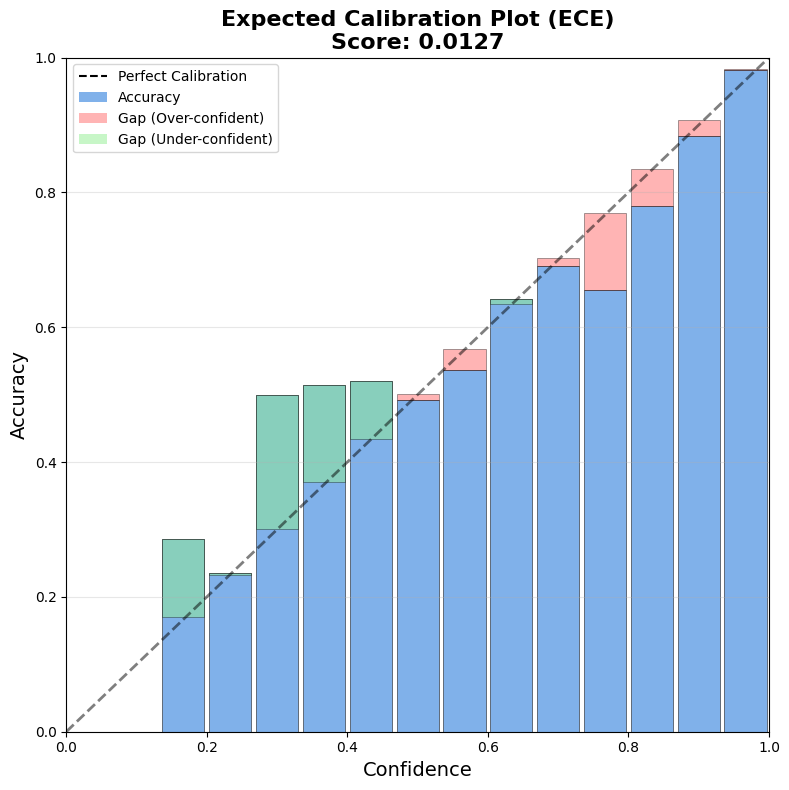

In [13]:
print("Calibration with Total Uncertainty:")
plot_ece_curve(bin_conf_total, bin_acc_total, bin_counts_total, ece_total, num_bins=NUM_BINS)

### Epistemic Uncertainty Calibration

Calibration with Epistemic Uncertainty:


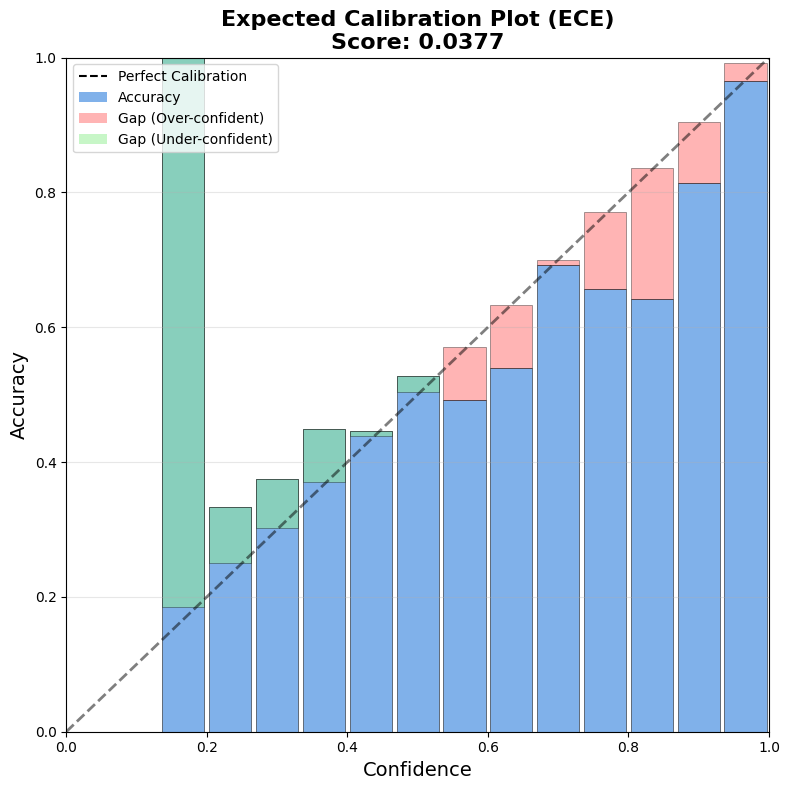

In [14]:
print("Calibration with Epistemic Uncertainty:")
plot_ece_curve(bin_conf_epistemic, bin_acc_epistemic, bin_counts_epistemic, ece_epistemic, num_bins=NUM_BINS)

## Negative Log-Likelihood (NLL) Analysis

Calculate NLL before and after shifting/scaling to compare calibration quality.

In [15]:
def calculate_nll(probs, labels):
    """
    Calculate Negative Log-Likelihood.
    
    Args:
        probs: Probability array [N, num_classes]
        labels: True labels [N]
    
    Returns:
        nll: Negative log-likelihood value
    """
    epsilon = 1e-15
    probs_clipped = np.clip(probs, epsilon, 1.0)
    correct_confidences = probs_clipped[np.arange(len(probs)), labels]
    nll = -np.mean(np.log(correct_confidences))
    return nll


# Calculate NLL BEFORE shifting/scaling (with scale=1.0, shift=0.0)
print("="*80)
print("NLL BEFORE Shifting/Scaling (Scale=1.0, Shift=0.0)")
print("="*80)

# Get logits without shifting
mu_logits_raw, var_epistemic_raw, var_total_raw, labels_raw = collect_logits_separate(
    net, cifar_loader, BATCH_SIZE, 
    scale=1.0, shift=0.0,  # NO shifting
    logit_min=LOGIT_MIN, logit_max=LOGIT_MAX, var_max=VAR_MAX
)

# Total Uncertainty - Before Shifting
if OUTPUT_METHOD == 'remax':
    output_total_raw = remax_analytical(mu_logits_raw, var_total_raw)
else:
    output_total_raw = softmax_analytical(mu_logits_raw, var_total_raw)

probs_total_raw = output_total_raw['mu_a']
probs_total_raw = probs_total_raw / probs_total_raw.sum(axis=1, keepdims=True)
nll_total_before = calculate_nll(probs_total_raw, labels_raw)

# Epistemic Uncertainty - Before Shifting
if OUTPUT_METHOD == 'remax':
    output_epistemic_raw = remax_analytical(mu_logits_raw, var_epistemic_raw)
else:
    output_epistemic_raw = softmax_analytical(mu_logits_raw, var_epistemic_raw)

probs_epistemic_raw = output_epistemic_raw['mu_a']
probs_epistemic_raw = probs_epistemic_raw / probs_epistemic_raw.sum(axis=1, keepdims=True)
nll_epistemic_before = calculate_nll(probs_epistemic_raw, labels_raw)

print(f"NLL (Total Uncertainty):     {nll_total_before:.4f}")
print(f"NLL (Epistemic Uncertainty): {nll_epistemic_before:.4f}")

# Calculate NLL AFTER shifting/scaling (with current SCALE and SHIFT)
print(f"\n{'='*80}")
print(f"NLL AFTER Shifting/Scaling (Scale={SCALE:.4f}, Shift={SHIFT:.4f})")
print("="*80)

nll_total_after = calculate_nll(probs_total, labels_clean)
nll_epistemic_after = calculate_nll(probs_epistemic, labels_clean)

print(f"NLL (Total Uncertainty):     {nll_total_after:.4f}")
print(f"NLL (Epistemic Uncertainty): {nll_epistemic_after:.4f}")

# Calculate improvements
print(f"\n{'='*80}")
print("NLL IMPROVEMENT (Negative values = worse)")
print("="*80)
nll_total_improvement = nll_total_before - nll_total_after
nll_epistemic_improvement = nll_epistemic_before - nll_epistemic_after

print(f"Total Uncertainty:     {nll_total_improvement:+.4f} ({'better' if nll_total_improvement > 0 else 'worse'})")
print(f"Epistemic Uncertainty: {nll_epistemic_improvement:+.4f} ({'better' if nll_epistemic_improvement > 0 else 'worse'})")

NLL BEFORE Shifting/Scaling (Scale=1.0, Shift=0.0)
NLL (Total Uncertainty):     1.1112
NLL (Epistemic Uncertainty): 2.6738

NLL AFTER Shifting/Scaling (Scale=10.3373, Shift=9.4423)
NLL (Total Uncertainty):     0.3310
NLL (Epistemic Uncertainty): 0.6125

NLL IMPROVEMENT (Negative values = worse)
Total Uncertainty:     +0.7802 (better)
Epistemic Uncertainty: +2.0614 (better)


### NLL Comparison Plot

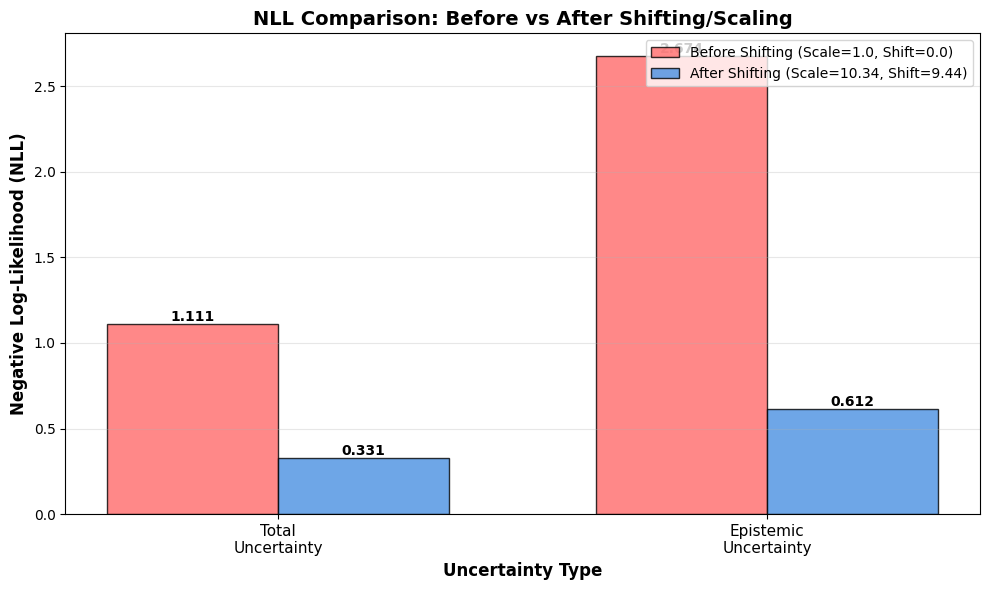


SUMMARY
Lower NLL = Better calibration

Best Total Uncertainty NLL:     0.3310 (After shifting)
Best Epistemic Uncertainty NLL: 0.6125 (After shifting)


In [16]:
# Create comparison plot
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Total\nUncertainty', 'Epistemic\nUncertainty']
before_values = [nll_total_before, nll_epistemic_before]
after_values = [nll_total_after, nll_epistemic_after]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, before_values, width, label='Before Shifting (Scale=1.0, Shift=0.0)', 
               color='#FF6B6B', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, after_values, width, label=f'After Shifting (Scale={SCALE:.2f}, Shift={SHIFT:.2f})', 
               color='#4A90E2', alpha=0.8, edgecolor='black', linewidth=1)

ax.set_xlabel('Uncertainty Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Negative Log-Likelihood (NLL)', fontsize=12, fontweight='bold')
ax.set_title('NLL Comparison: Before vs After Shifting/Scaling', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Lower NLL = Better calibration")
print(f"\nBest Total Uncertainty NLL:     {min(nll_total_before, nll_total_after):.4f} "
      f"({'Before' if nll_total_before < nll_total_after else 'After'} shifting)")
print(f"Best Epistemic Uncertainty NLL: {min(nll_epistemic_before, nll_epistemic_after):.4f} "
      f"({'Before' if nll_epistemic_before < nll_epistemic_after else 'After'} shifting)")

## Example Predictions: Normal Case and Transformation Effect

Let's examine specific examples to understand how the model behaves:
1. **Normal Prediction** - A correctly classified example
2. **Transformation Correction** - Where logits predict wrong class but transformation (Remax/Softmax) corrects it

### Example 1: Normal Correct Prediction

Finding an example where the model predicts correctly.

EXAMPLE 1: NORMAL CORRECT PREDICTION
Sample Index: 0
True Label: cat
Predicted from Logits: cat
Predicted after Remax: cat
All agree: ✓


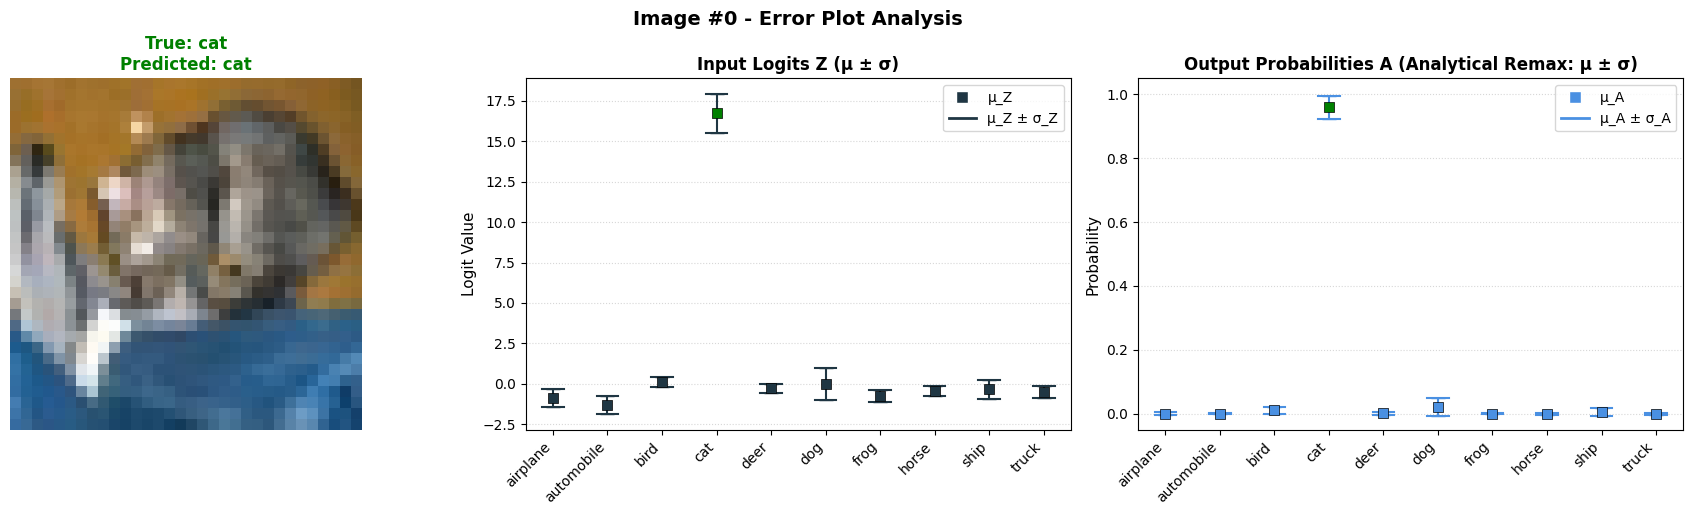


Image #0 Analysis
True Label: cat
Predicted from Logits: cat
Predicted after Remax: cat
Prediction Probability: 0.9585 ± 0.0365
True Class Probability: 0.9585 ± 0.0365
Entropy: 0.2283
Total Variance: 0.0025
Logits Correct: ✓
Final Correct: ✓



In [17]:
# Find a correctly predicted example
correct_mask = predictions_total == labels_clean
correct_indices = np.where(correct_mask)[0]

if len(correct_indices) > 0:
    # Pick a random correct prediction (or the first one)
    normal_example_idx = correct_indices[0]
    
    print("="*80)
    print("EXAMPLE 1: NORMAL CORRECT PREDICTION")
    print("="*80)
    print(f"Sample Index: {normal_example_idx}")
    
    # Get logits predictions
    logit_pred_label = np.argmax(mu_logits_clean[normal_example_idx])
    prob_pred_label = predictions_total[normal_example_idx]
    true_label_val = labels_clean[normal_example_idx]
    
    print(f"True Label: {CIFAR10_CLASSES[true_label_val]}")
    print(f"Predicted from Logits: {CIFAR10_CLASSES[logit_pred_label]}")
    print(f"Predicted after {OUTPUT_METHOD.title()}: {CIFAR10_CLASSES[prob_pred_label]}")
    print(f"All agree: {'✓' if logit_pred_label == prob_pred_label == true_label_val else '✗'}")
    
    # Get image
    img_data = cifar_set.data[normal_example_idx]
    img = denormalize_image(img_data)
    
    # Plot
    plot_error_bars(
        img, true_label_val,
        mu_logits_clean[normal_example_idx],
        var_total_clean[normal_example_idx],
        method=OUTPUT_METHOD,
        image_idx=normal_example_idx
    )
else:
    print("No correct predictions found!")

### Example 2: Transformation Correction

Finding an example where the top logit class is WRONG, but after transformation it becomes CORRECT.

This demonstrates how uncertainty-aware transformations (Remax/Softmax with variance) can improve predictions by incorporating uncertainty information.

Correction indices: [ 680 1574 2747 2840 3724 6901 8212 8792 9734]
EXAMPLE 2: TRANSFORMATION CORRECTION (REMAX)
Sample Index: 680

This example shows how remax can CORRECT a wrong logit prediction!

True Label: truck
Predicted from Logits (RAW): automobile ✗ WRONG
Predicted after Remax: truck ✓ CORRECT

Top 3 Logits (before transformation):
1. automobile   :    9.303
2. truck        :    9.213
3. airplane     :    0.699

Top 3 Probabilities (after remax):
1. truck        :   0.4906 ← TRUE
2. automobile   :   0.4667 
3. airplane     :   0.0408 

Why the correction happened:
The transformation considers BOTH the mean logits AND their variances.
High variance in the wrong class can reduce its final probability,
allowing the correct class to win even if its logit was initially lower.


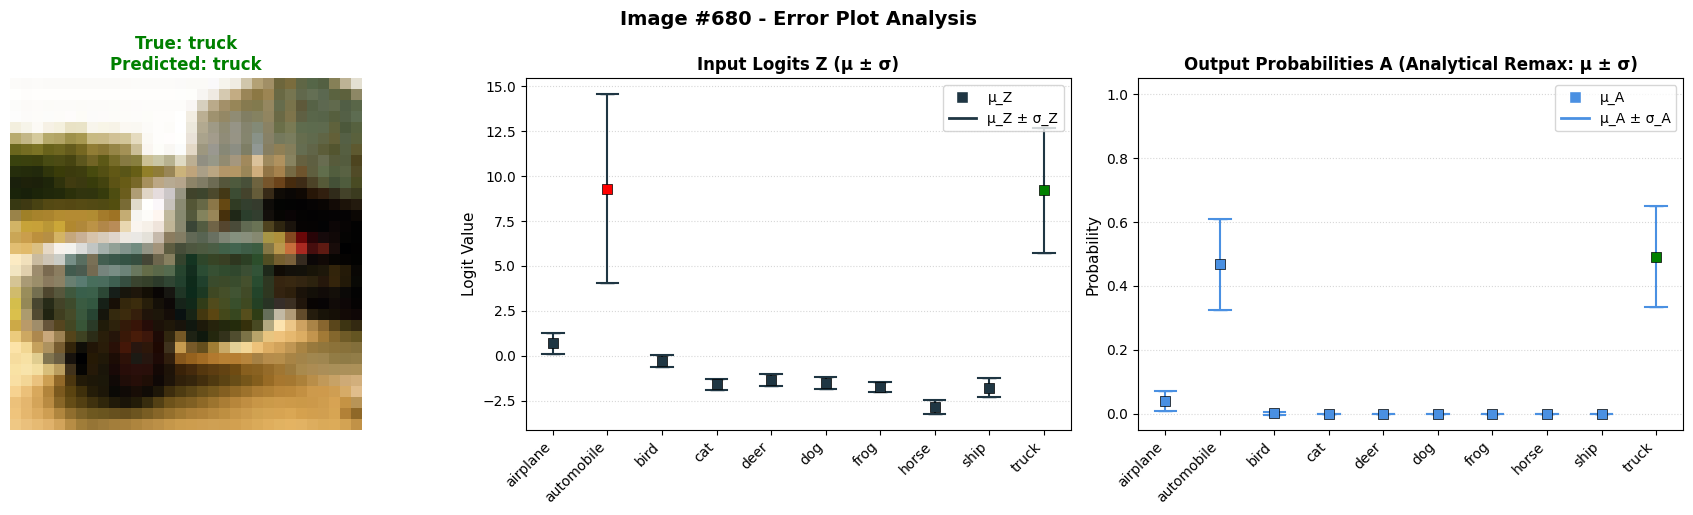


Image #680 Analysis
True Label: truck
Predicted from Logits: automobile
Predicted after Remax: truck
Prediction Probability: 0.4913 ± 0.1585
True Class Probability: 0.4913 ± 0.1585
Entropy: 0.8471
Total Variance: 0.0464
Logits Correct: ✗
Final Correct: ✓


KEY OBSERVATION:
Look at the error bars in the plots above!
The wrong prediction (from logits) likely has HIGH uncertainty (large error bars),
while the correct prediction has LOWER uncertainty.
The remax transformation leverages this to make the right choice!



In [18]:
# Find examples where logits predict wrong but transformation predicts correctly
logit_predictions = np.argmax(mu_logits_clean, axis=1)
prob_predictions = predictions_total

# Find cases where: logits wrong BUT transformation correct
logit_wrong_mask = logit_predictions != labels_clean
prob_correct_mask = prob_predictions == labels_clean
correction_mask = logit_wrong_mask & prob_correct_mask

correction_indices = np.where(correction_mask)[0]
print(f"Correction indices: {correction_indices}")

if len(correction_indices) > 0:
    # Pick the first correction example
    correction_example_idx = correction_indices[0]
    
    print("="*80)
    print(f"EXAMPLE 2: TRANSFORMATION CORRECTION ({OUTPUT_METHOD.upper()})")
    print("="*80)
    print(f"Sample Index: {correction_example_idx}")
    print(f"\nThis example shows how {OUTPUT_METHOD} can CORRECT a wrong logit prediction!")
    
    # Get predictions
    logit_pred_label = logit_predictions[correction_example_idx]
    prob_pred_label = prob_predictions[correction_example_idx]
    true_label_val = labels_clean[correction_example_idx]
    
    print(f"\nTrue Label: {CIFAR10_CLASSES[true_label_val]}")
    print(f"Predicted from Logits (RAW): {CIFAR10_CLASSES[logit_pred_label]} ✗ WRONG")
    print(f"Predicted after {OUTPUT_METHOD.title()}: {CIFAR10_CLASSES[prob_pred_label]} ✓ CORRECT")
    
    # Show the top 3 logits vs top 3 probabilities
    print(f"\n{'='*40}")
    print("Top 3 Logits (before transformation):")
    print(f"{'='*40}")
    top3_logit_idx = np.argsort(mu_logits_clean[correction_example_idx])[::-1][:3]
    for rank, idx in enumerate(top3_logit_idx, 1):
        logit_val = mu_logits_clean[correction_example_idx][idx]
        print(f"{rank}. {CIFAR10_CLASSES[idx]:12s} : {logit_val:8.3f}")
    
    print(f"\n{'='*40}")
    print(f"Top 3 Probabilities (after {OUTPUT_METHOD}):")
    print(f"{'='*40}")
    top3_prob_idx = np.argsort(probs_total[correction_example_idx])[::-1][:3]
    for rank, idx in enumerate(top3_prob_idx, 1):
        prob_val = probs_total[correction_example_idx][idx]
        marker = "← TRUE" if idx == true_label_val else ""
        print(f"{rank}. {CIFAR10_CLASSES[idx]:12s} : {prob_val:8.4f} {marker}")
    
    print(f"\n{'='*40}")
    print("Why the correction happened:")
    print(f"{'='*40}")
    print(f"The transformation considers BOTH the mean logits AND their variances.")
    print(f"High variance in the wrong class can reduce its final probability,")
    print(f"allowing the correct class to win even if its logit was initially lower.")
    
    # Get image
    img_data = cifar_set.data[correction_example_idx]
    img = denormalize_image(img_data)
    
    # Plot
    plot_error_bars(
        img, true_label_val,
        mu_logits_clean[correction_example_idx],
        var_total_clean[correction_example_idx],
        method=OUTPUT_METHOD,
        image_idx=correction_example_idx
    )
    
    print(f"\n{'='*80}")
    print("KEY OBSERVATION:")
    print(f"{'='*80}")
    print(f"Look at the error bars in the plots above!")
    print(f"The wrong prediction (from logits) likely has HIGH uncertainty (large error bars),")
    print(f"while the correct prediction has LOWER uncertainty.")
    print(f"The {OUTPUT_METHOD} transformation leverages this to make the right choice!")
    print(f"{'='*80}\n")
    
else:
    print("="*80)
    print("NO TRANSFORMATION CORRECTIONS FOUND")
    print("="*80)
    print(f"All predictions where logits are wrong remain wrong after {OUTPUT_METHOD}.")
    print(f"This suggests the model's uncertainty estimates may not be well-calibrated,")
    print(f"or the transformation parameters need tuning.")
    print("="*80)

## Top 10 Images with Highest Entropy

Analyzing the most uncertain predictions based on entropy.

TOP 10 HIGHEST ENTROPY IMAGES (Total Uncertainty)

Rank 1: Sample #3445 | Entropy: 2.2533


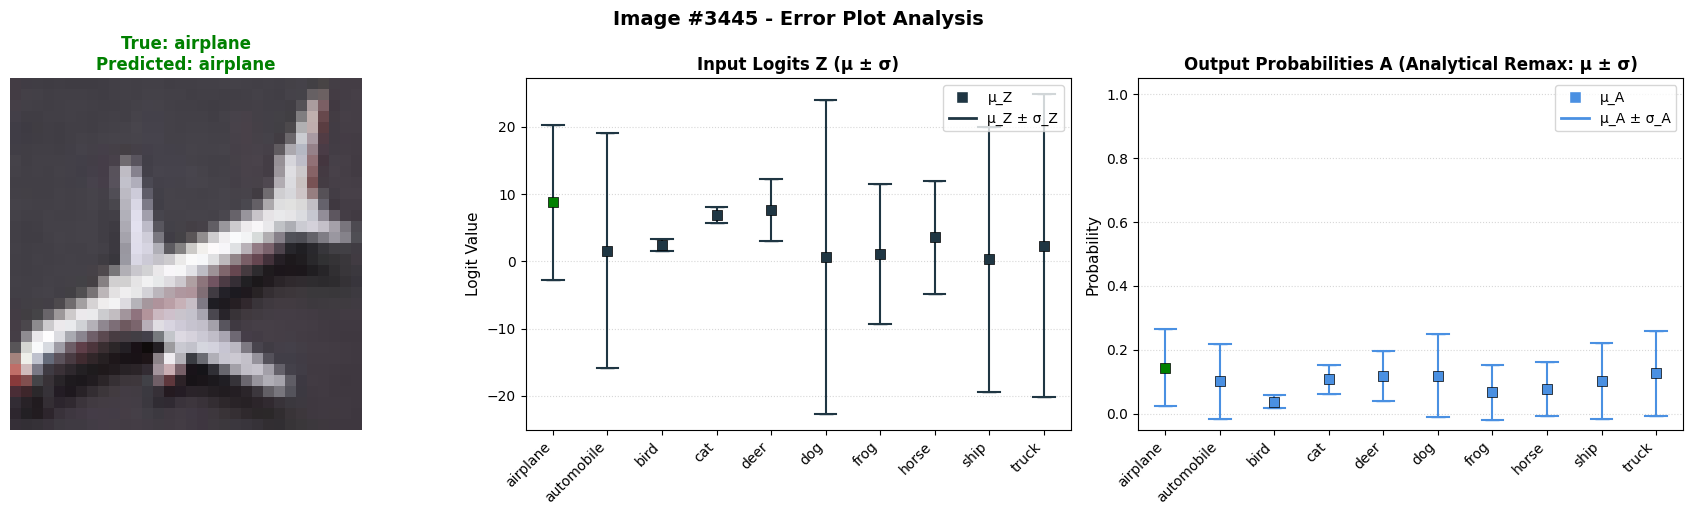


Image #3445 Analysis
True Label: airplane
Predicted from Logits: airplane
Predicted after Remax: airplane
Prediction Probability: 0.1448 ± 0.1210
True Class Probability: 0.1448 ± 0.1210
Entropy: 2.2623
Total Variance: 0.1004
Logits Correct: ✓
Final Correct: ✓


Rank 2: Sample #5037 | Entropy: 2.1994


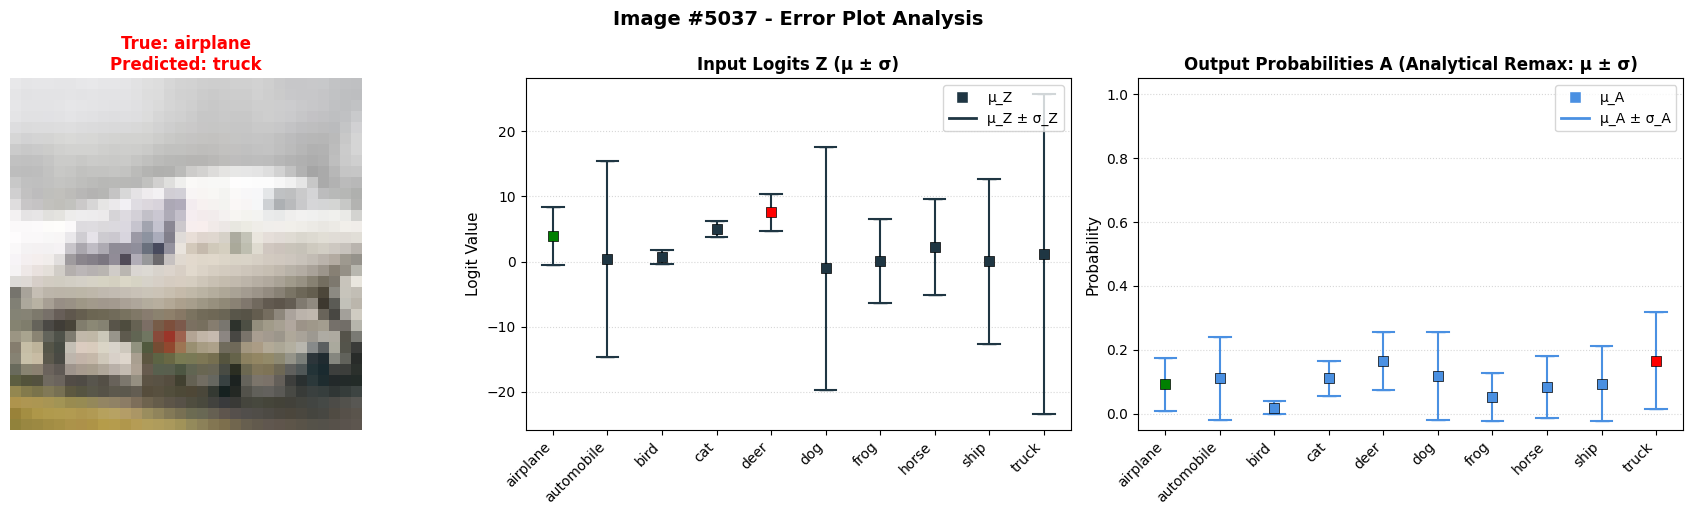


Image #5037 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: truck
Prediction Probability: 0.1664 ± 0.1526
True Class Probability: 0.0919 ± 0.0838
Entropy: 2.2164
Total Variance: 0.1064
Logits Correct: ✗
Final Correct: ✗


Rank 3: Sample #1665 | Entropy: 2.1702


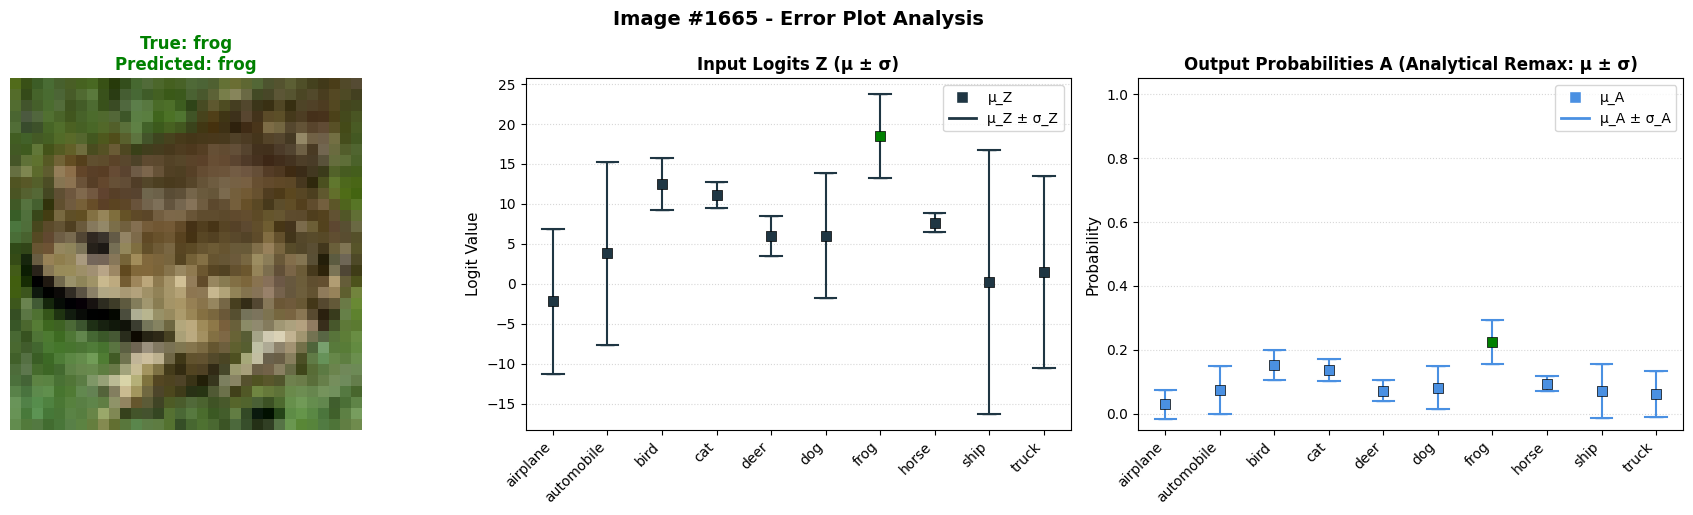


Image #1665 Analysis
True Label: frog
Predicted from Logits: frog
Predicted after Remax: frog
Prediction Probability: 0.2252 ± 0.0679
True Class Probability: 0.2252 ± 0.0679
Entropy: 2.1731
Total Variance: 0.0343
Logits Correct: ✓
Final Correct: ✓


Rank 4: Sample #2249 | Entropy: 2.1656


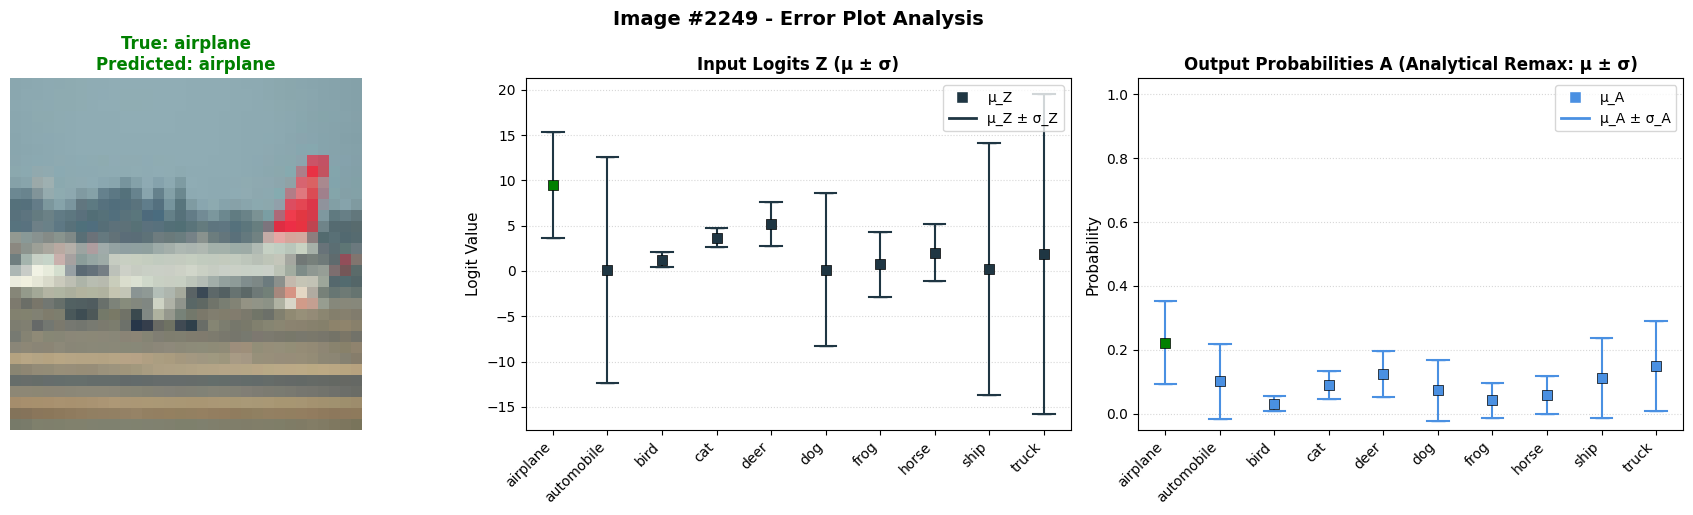


Image #2249 Analysis
True Label: airplane
Predicted from Logits: airplane
Predicted after Remax: airplane
Prediction Probability: 0.2231 ± 0.1302
True Class Probability: 0.2231 ± 0.1302
Entropy: 2.1772
Total Variance: 0.0896
Logits Correct: ✓
Final Correct: ✓


Rank 5: Sample #7701 | Entropy: 2.1500


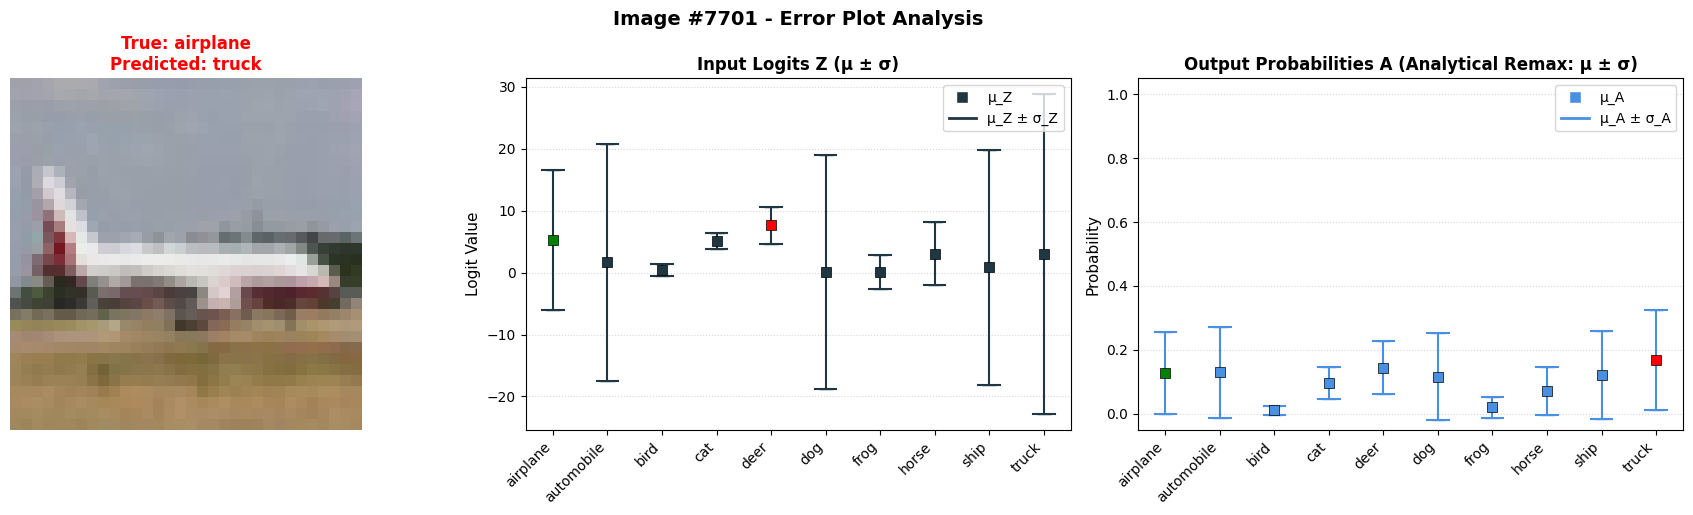


Image #7701 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: truck
Prediction Probability: 0.1692 ± 0.1563
True Class Probability: 0.1284 ± 0.1274
Entropy: 2.1629
Total Variance: 0.1139
Logits Correct: ✗
Final Correct: ✗


Rank 6: Sample #6363 | Entropy: 2.1445


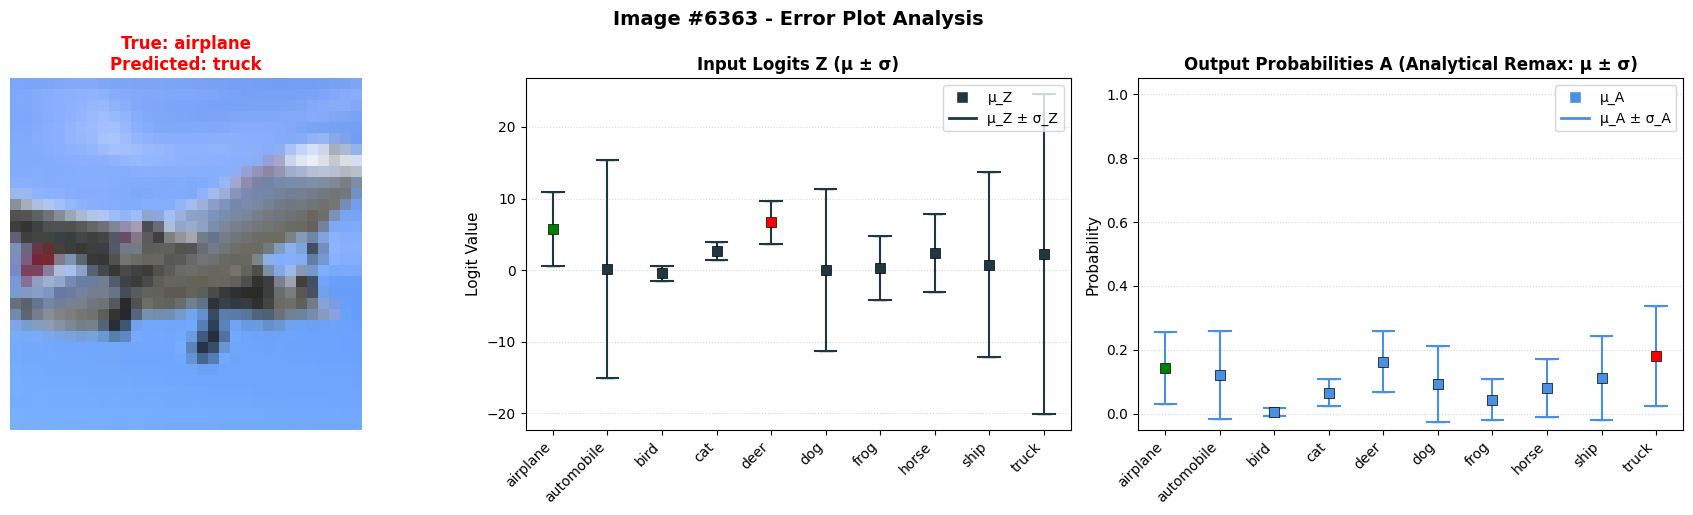


Image #6363 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: truck
Prediction Probability: 0.1806 ± 0.1566
True Class Probability: 0.1433 ± 0.1125
Entropy: 2.1595
Total Variance: 0.1103
Logits Correct: ✗
Final Correct: ✗


Rank 7: Sample #5798 | Entropy: 2.1428


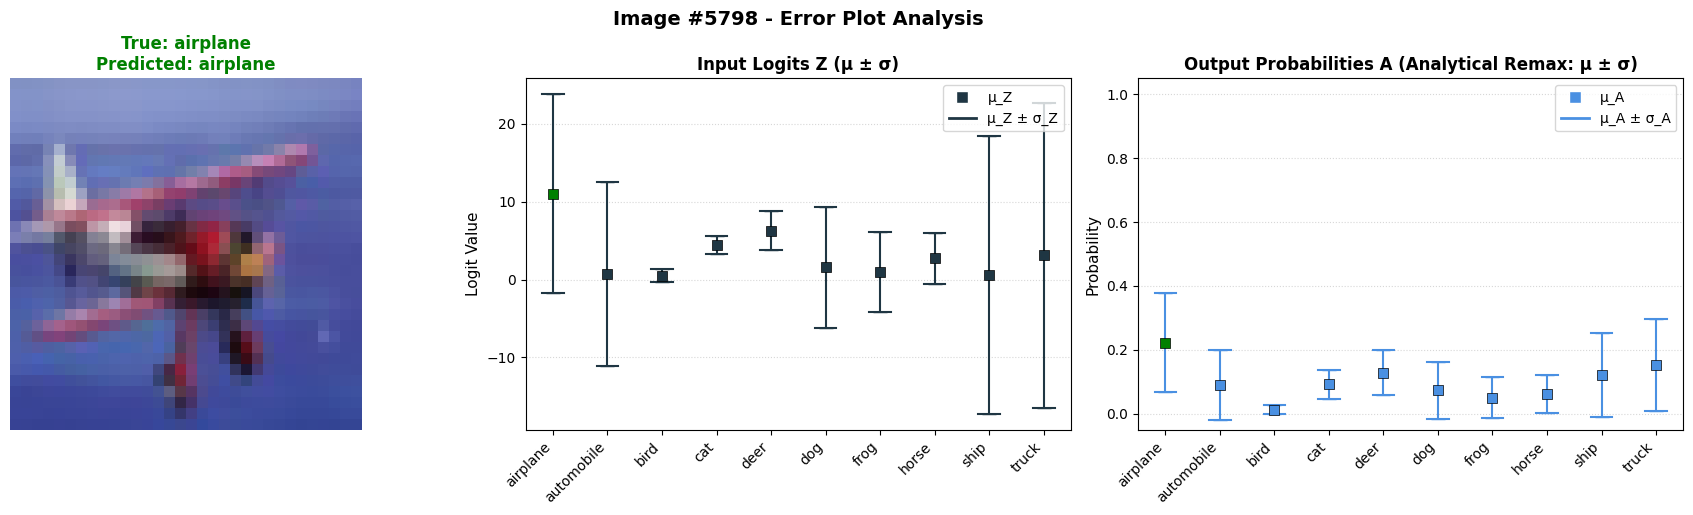


Image #5798 Analysis
True Label: airplane
Predicted from Logits: airplane
Predicted after Remax: airplane
Prediction Probability: 0.2224 ± 0.1550
True Class Probability: 0.2224 ± 0.1550
Entropy: 2.1520
Total Variance: 0.0969
Logits Correct: ✓
Final Correct: ✓


Rank 8: Sample #6350 | Entropy: 2.1302


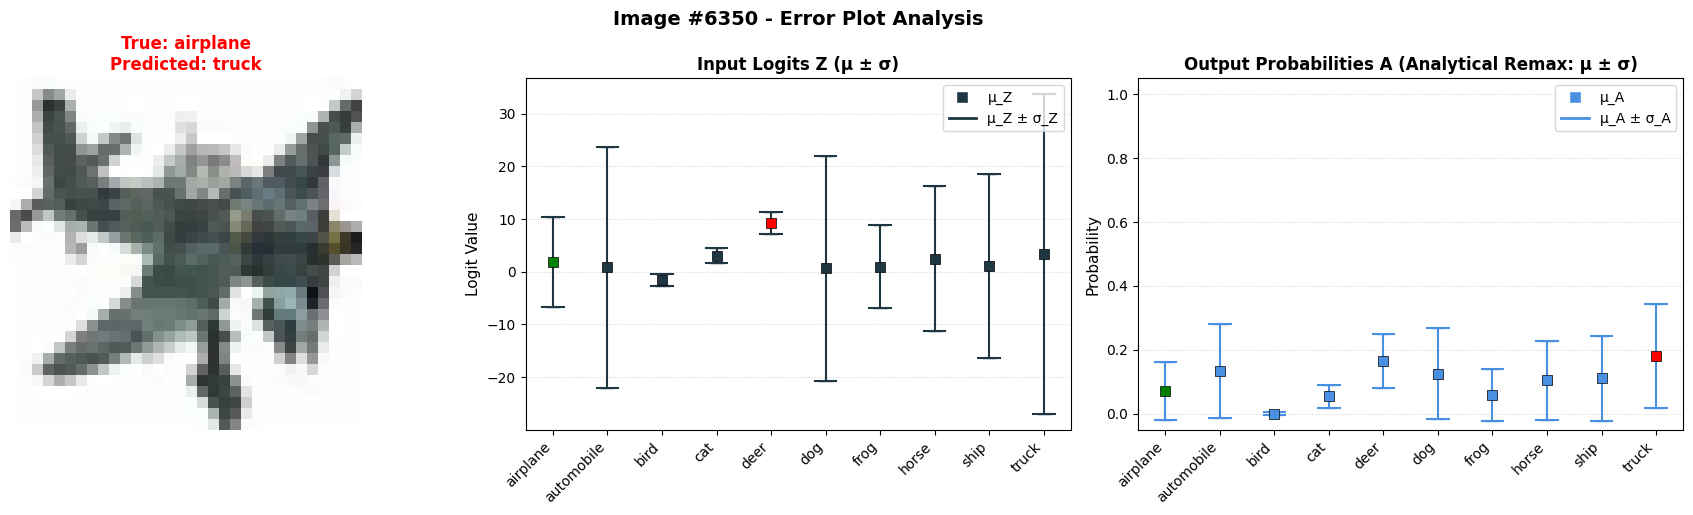


Image #6350 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: truck
Prediction Probability: 0.1810 ± 0.1628
True Class Probability: 0.0724 ± 0.0910
Entropy: 2.1436
Total Variance: 0.1247
Logits Correct: ✗
Final Correct: ✗


Rank 9: Sample #4817 | Entropy: 2.1253


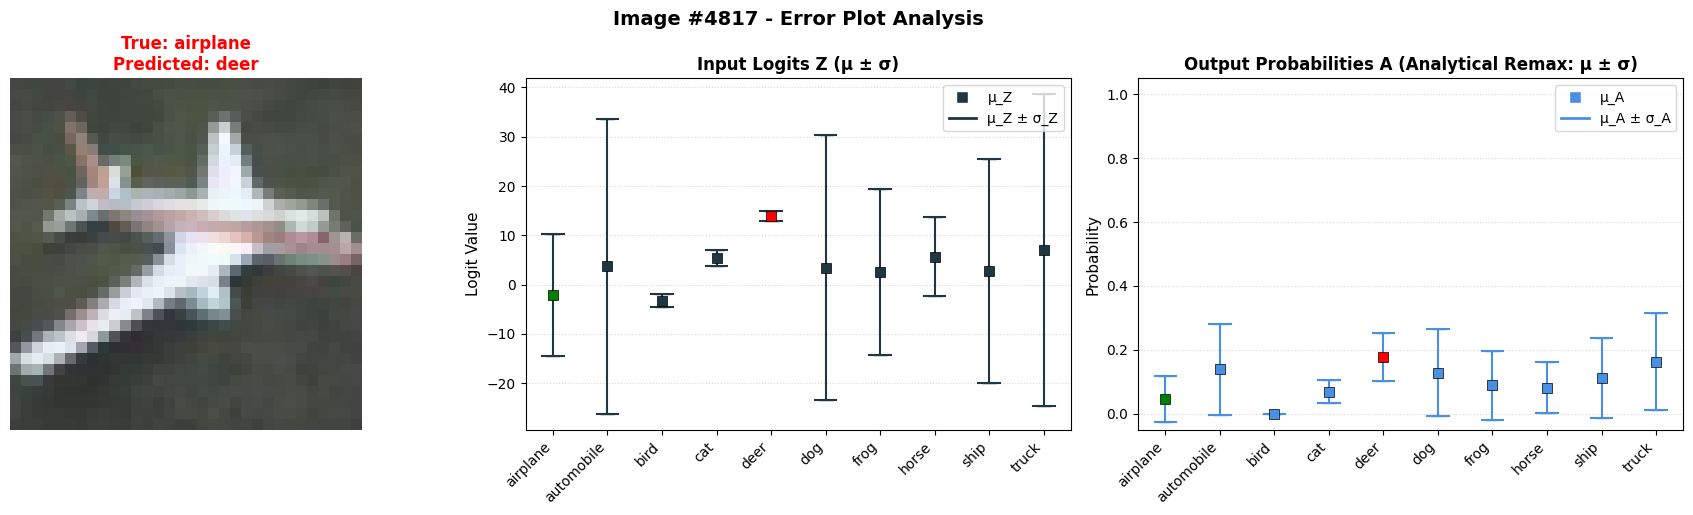


Image #4817 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: deer
Prediction Probability: 0.1783 ± 0.0756
True Class Probability: 0.0457 ± 0.0719
Entropy: 2.1358
Total Variance: 0.1074
Logits Correct: ✗
Final Correct: ✗


Rank 10: Sample #6206 | Entropy: 2.1222


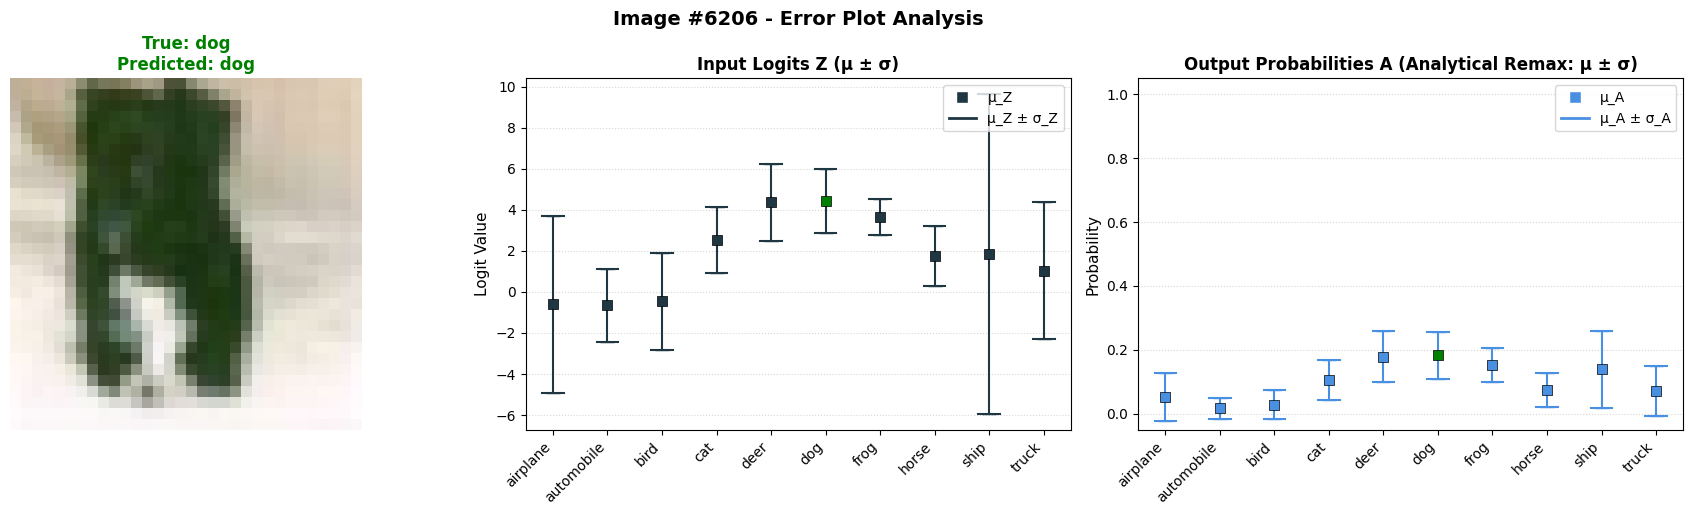


Image #6206 Analysis
True Label: dog
Predicted from Logits: dog
Predicted after Remax: dog
Prediction Probability: 0.1835 ± 0.0739
True Class Probability: 0.1835 ± 0.0739
Entropy: 2.1286
Total Variance: 0.0508
Logits Correct: ✓
Final Correct: ✓



In [19]:
# Calculate entropy for total uncertainty
entropy_total = calculate_entropy(probs_total)

# Find top 10 highest entropy
top_entropy_indices = np.argsort(entropy_total)[::-1][:10]

print("="*60)
print("TOP 10 HIGHEST ENTROPY IMAGES (Total Uncertainty)")
print("="*60)

for rank, idx in enumerate(top_entropy_indices):
    print(f"\nRank {rank+1}: Sample #{idx} | Entropy: {entropy_total[idx]:.4f}")
    
    # Get image (CIFAR-10 .data is uint8, HWC format)
    img_data = cifar_set.data[idx]
    img = denormalize_image(img_data)
    
    true_label = labels_clean[idx]
    
    # Plot
    plot_error_bars(
        img, true_label, 
        mu_logits_clean[idx], 
        var_total_clean[idx],
        method=OUTPUT_METHOD,
        image_idx=idx
    )

## Top 10 Images with Highest Total Variance

Analyzing predictions with the highest total variance across all classes.

TOP 10 HIGHEST TOTAL VARIANCE IMAGES

Rank 1: Sample #6161 | Total Variance: 0.1844


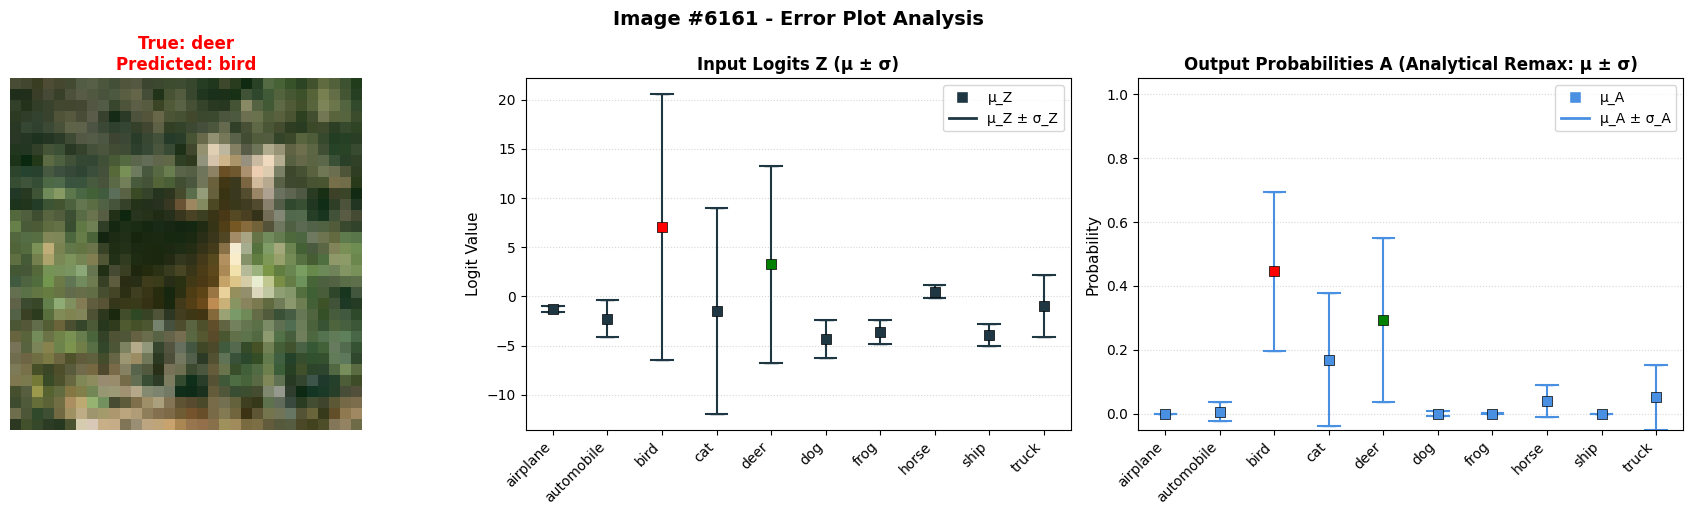


Image #6161 Analysis
True Label: deer
Predicted from Logits: bird
Predicted after Remax: bird
Prediction Probability: 0.4456 ± 0.2490
True Class Probability: 0.2938 ± 0.2567
Entropy: 1.3409
Total Variance: 0.1844
Logits Correct: ✗
Final Correct: ✗


Rank 2: Sample #8169 | Total Variance: 0.1781


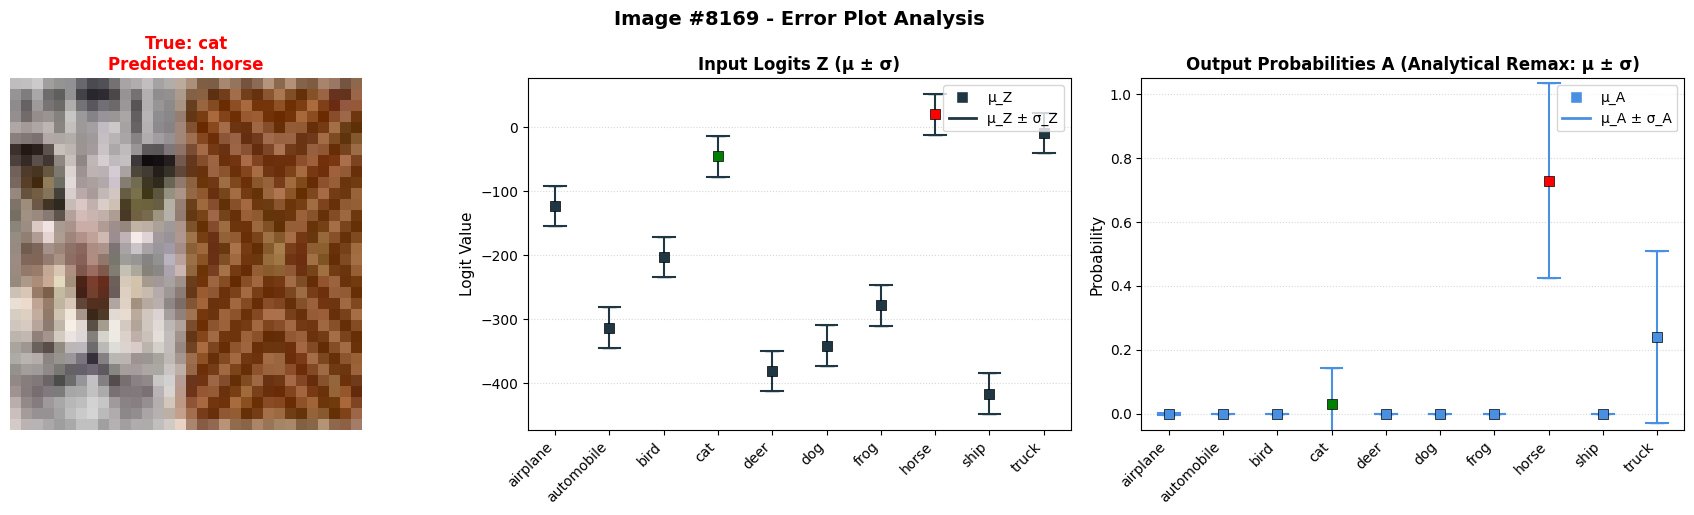


Image #8169 Analysis
True Label: cat
Predicted from Logits: horse
Predicted after Remax: horse
Prediction Probability: 0.7291 ± 0.3054
True Class Probability: 0.0310 ± 0.1132
Entropy: 0.6808
Total Variance: 0.1781
Logits Correct: ✗
Final Correct: ✗


Rank 3: Sample #2679 | Total Variance: 0.1736


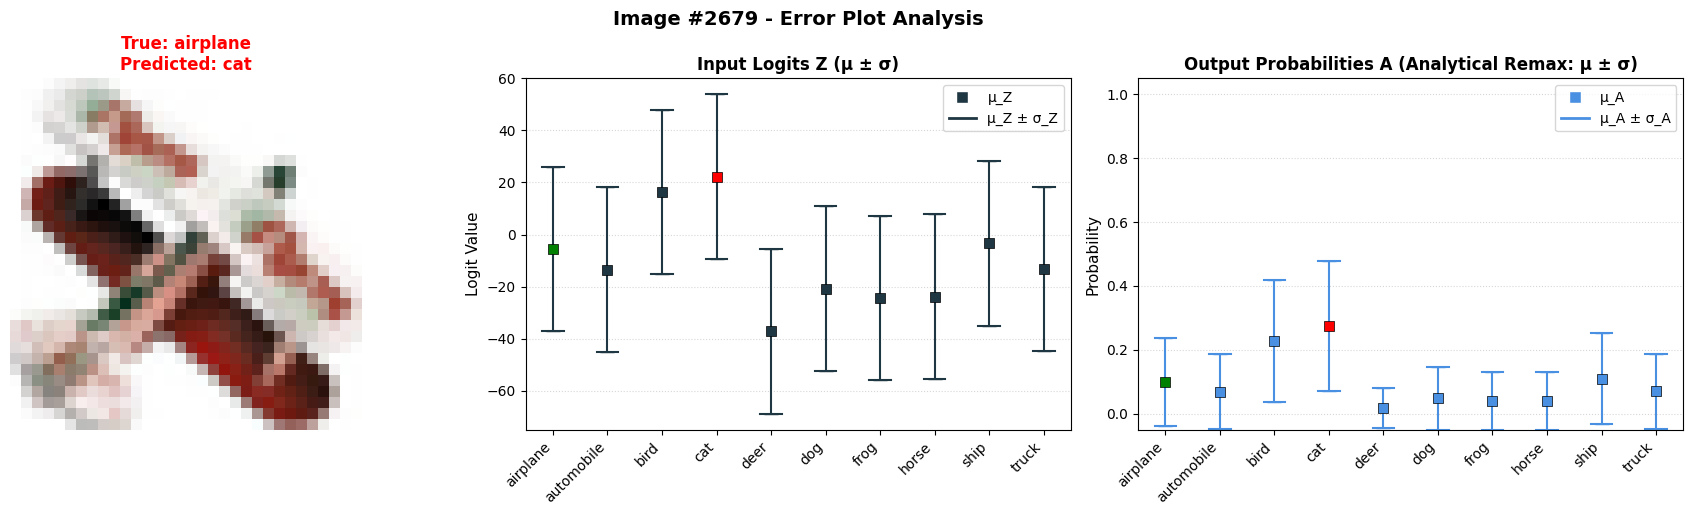


Image #2679 Analysis
True Label: airplane
Predicted from Logits: cat
Predicted after Remax: cat
Prediction Probability: 0.2738 ± 0.2028
True Class Probability: 0.0999 ± 0.1371
Entropy: 2.0193
Total Variance: 0.1736
Logits Correct: ✗
Final Correct: ✗


Rank 4: Sample #5794 | Total Variance: 0.1602


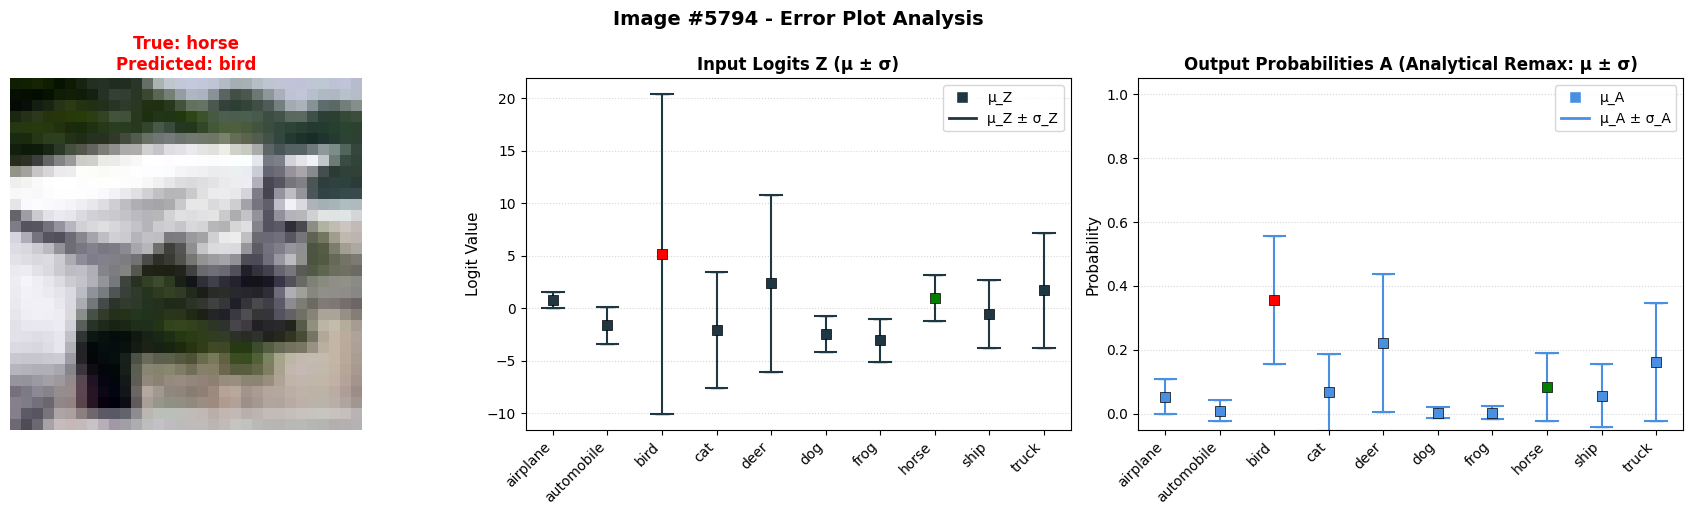


Image #5794 Analysis
True Label: horse
Predicted from Logits: bird
Predicted after Remax: bird
Prediction Probability: 0.3574 ± 0.2003
True Class Probability: 0.0842 ± 0.1052
Entropy: 1.7940
Total Variance: 0.1602
Logits Correct: ✗
Final Correct: ✗


Rank 5: Sample #9294 | Total Variance: 0.1573


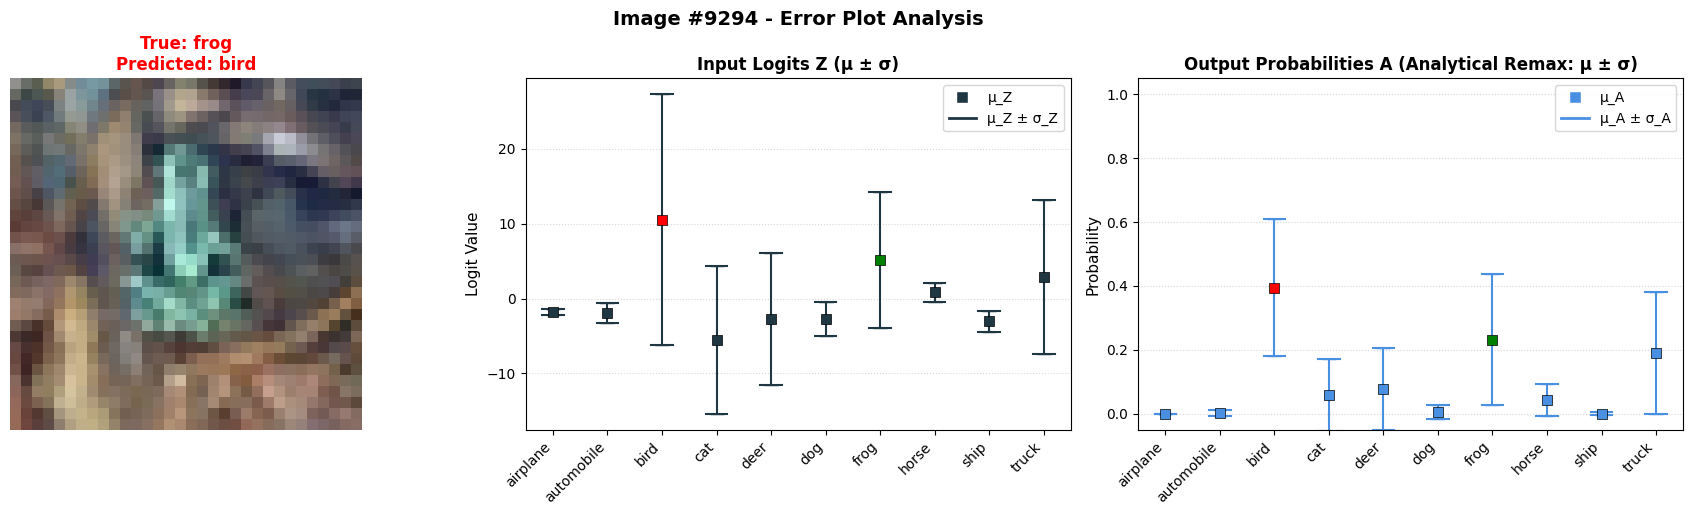


Image #9294 Analysis
True Label: frog
Predicted from Logits: bird
Predicted after Remax: bird
Prediction Probability: 0.3952 ± 0.2143
True Class Probability: 0.2323 ± 0.2059
Entropy: 1.5666
Total Variance: 0.1573
Logits Correct: ✗
Final Correct: ✗


Rank 6: Sample #4802 | Total Variance: 0.1553


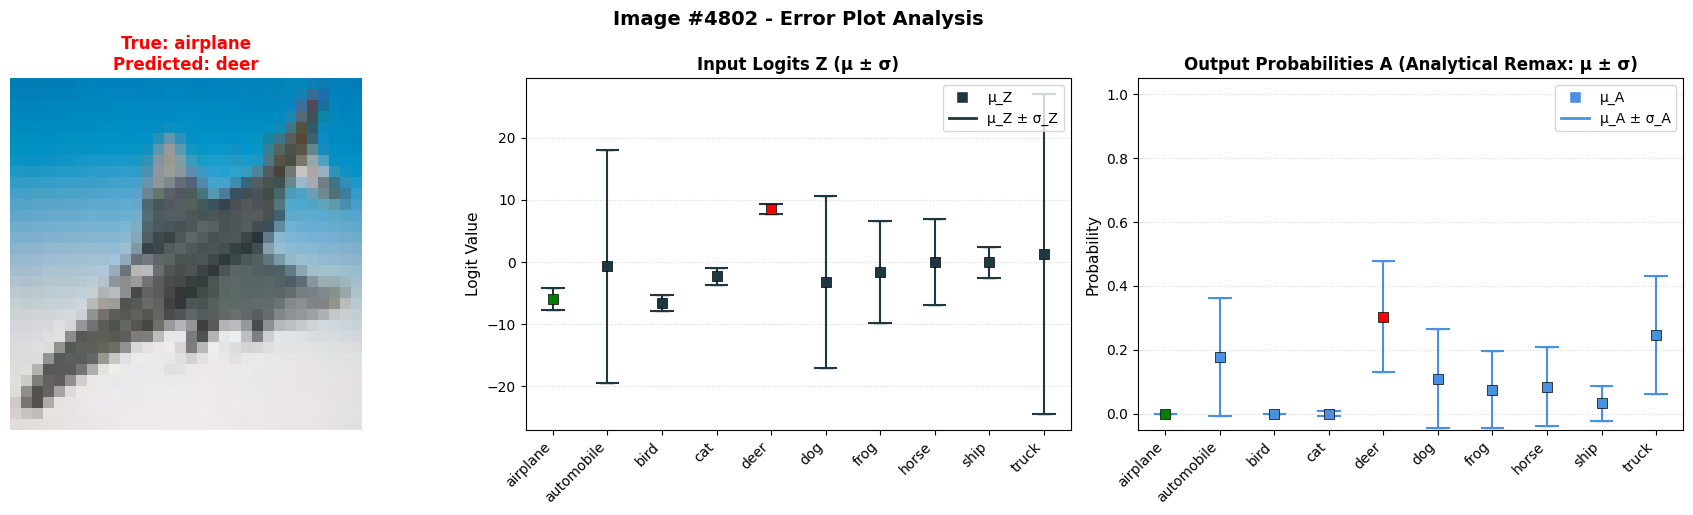


Image #4802 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: deer
Prediction Probability: 0.3043 ± 0.1741
True Class Probability: 0.0000 ± 0.0007
Entropy: 1.7824
Total Variance: 0.1553
Logits Correct: ✗
Final Correct: ✗


Rank 7: Sample #2216 | Total Variance: 0.1543


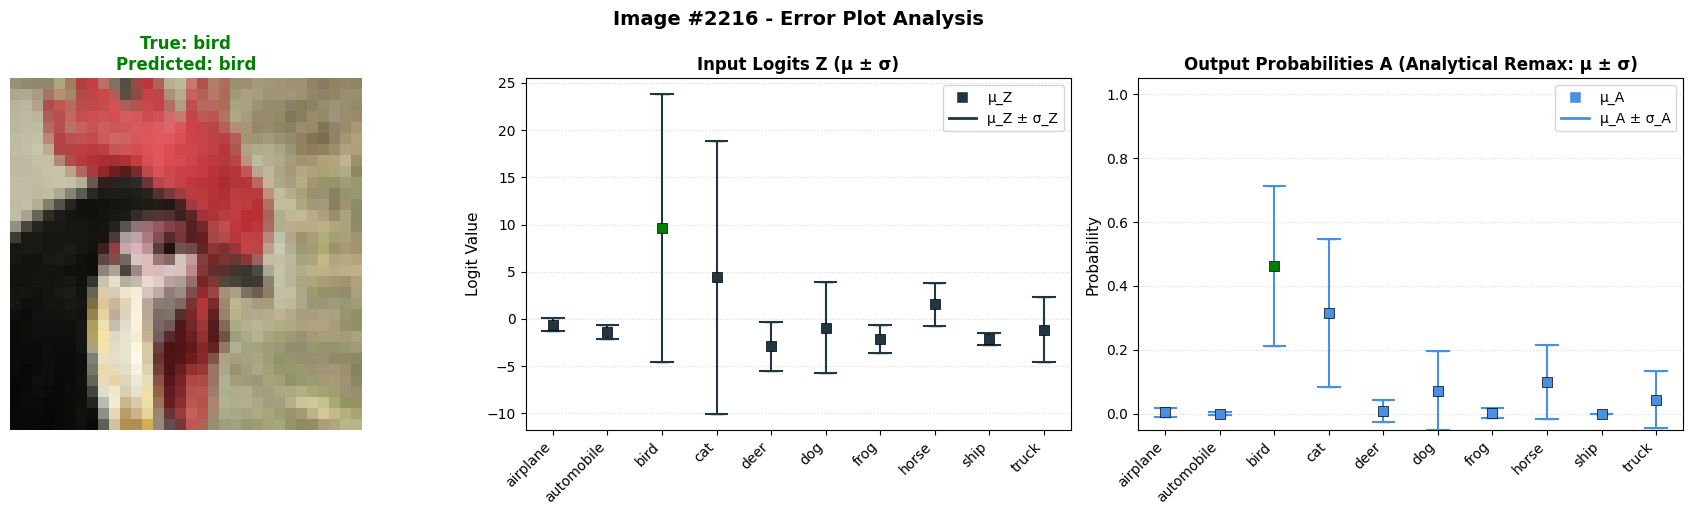


Image #2216 Analysis
True Label: bird
Predicted from Logits: bird
Predicted after Remax: bird
Prediction Probability: 0.4628 ± 0.2498
True Class Probability: 0.4628 ± 0.2498
Entropy: 1.3668
Total Variance: 0.1543
Logits Correct: ✓
Final Correct: ✓


Rank 8: Sample #1879 | Total Variance: 0.1543


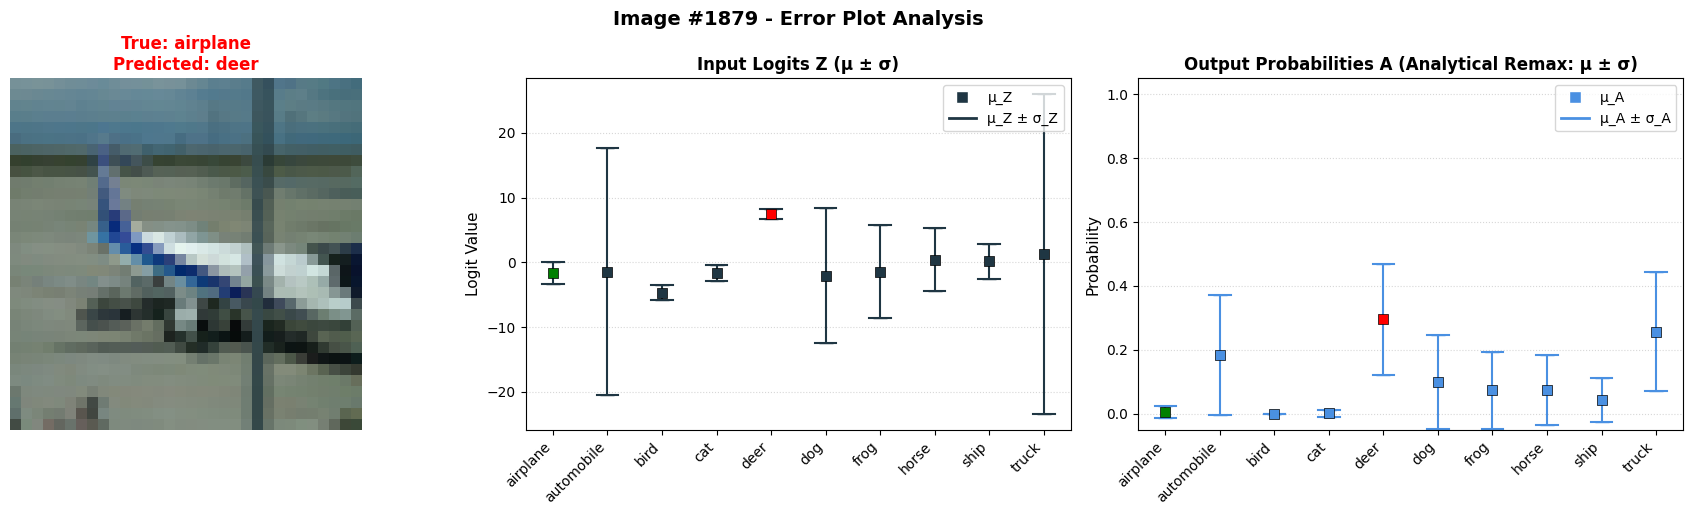


Image #1879 Analysis
True Label: airplane
Predicted from Logits: deer
Predicted after Remax: deer
Prediction Probability: 0.2959 ± 0.1741
True Class Probability: 0.0056 ± 0.0193
Entropy: 1.8189
Total Variance: 0.1543
Logits Correct: ✗
Final Correct: ✗


Rank 9: Sample #1138 | Total Variance: 0.1540


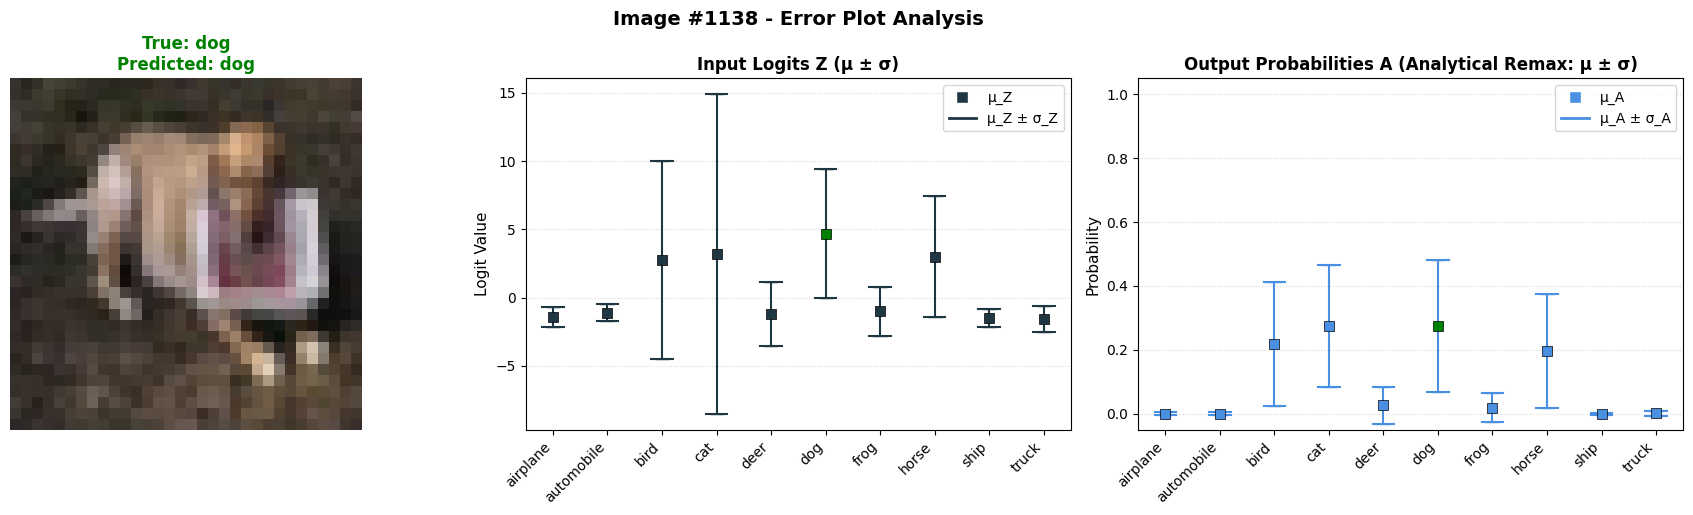


Image #1138 Analysis
True Label: dog
Predicted from Logits: dog
Predicted after Remax: dog
Prediction Probability: 0.2747 ± 0.2073
True Class Probability: 0.2747 ± 0.2073
Entropy: 1.5520
Total Variance: 0.1540
Logits Correct: ✓
Final Correct: ✓


Rank 10: Sample #1538 | Total Variance: 0.1519


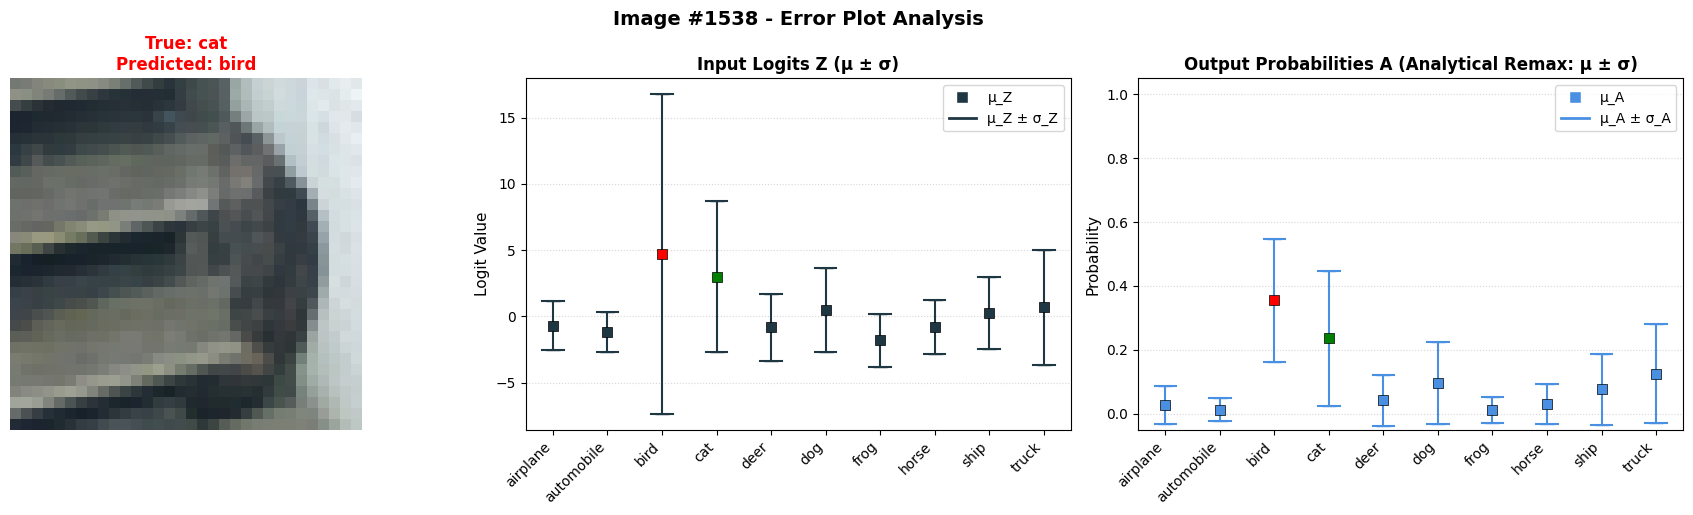


Image #1538 Analysis
True Label: cat
Predicted from Logits: bird
Predicted after Remax: bird
Prediction Probability: 0.3548 ± 0.1935
True Class Probability: 0.2368 ± 0.2115
Entropy: 1.8472
Total Variance: 0.1519
Logits Correct: ✗
Final Correct: ✗



In [20]:
# Calculate total variance
total_variance = calculate_total_variance(var_probs_total)

# Find top 10 highest variance
top_variance_indices = np.argsort(total_variance)[::-1][:10]

print("="*60)
print("TOP 10 HIGHEST TOTAL VARIANCE IMAGES")
print("="*60)

for rank, idx in enumerate(top_variance_indices):
    print(f"\nRank {rank+1}: Sample #{idx} | Total Variance: {total_variance[idx]:.4f}")
    
    # Get image (CIFAR-10 .data is uint8, HWC format)
    img_data = cifar_set.data[idx]
    img = denormalize_image(img_data)
    
    true_label = labels_clean[idx]
    
    # Plot
    plot_error_bars(
        img, true_label, 
        mu_logits_clean[idx], 
        var_total_clean[idx],
        method=OUTPUT_METHOD,
        image_idx=idx
    )

## OOD Detection: Entropy Distributions

Comparing entropy distributions for In-Distribution (CIFAR-10) vs Out-of-Distribution (SVHN).

In [21]:
def get_ood_metrics(net, loader, use_total_variance=True, description="Processing"):
    """
    Compute uncertainty metrics for OOD detection.
    
    Returns:
        Dictionary with entropy and variance arrays
    """
    all_probs = []
    all_var_probs = []
    
    net.eval()
    
    for data, target in tqdm(loader, desc=description):
        m_pred_raw, v_pred_raw = net(data)
        
        current_batch_size = len(target)
        m_pred_2d = m_pred_raw.reshape(current_batch_size, -1)
        v_pred_2d = v_pred_raw.reshape(current_batch_size, -1)
        
        m_epistemic = m_pred_2d[:, ::2]
        v_epistemic = v_pred_2d[:, ::2]
        m_aleatoric = m_pred_2d[:, 1::2]
        
        # Scale
        m_epistemic_final = (m_epistemic * SCALE) + SHIFT
        v_epistemic_scaled = v_epistemic * (SCALE ** 2)
        m_aleatoric_scaled = m_aleatoric * (SCALE ** 2)
        
        # Select variance
        if use_total_variance:
            v_used = m_aleatoric_scaled + v_epistemic_scaled
        else:
            v_used = v_epistemic_scaled
            
        v_used = np.clip(v_used, 1e-6, VAR_MAX)
        
        # Apply transformation
        if OUTPUT_METHOD == 'remax':
            output = remax_analytical(m_epistemic_final, v_used)
        else:
            output = softmax_analytical(m_epistemic_final, v_used)
        
        probs = output['mu_a']
        probs = probs / probs.sum(axis=1, keepdims=True)
        variances = output['sigma_a_sq']
        
        all_probs.append(probs)
        all_var_probs.append(variances)
    
    all_probs = np.concatenate(all_probs, axis=0)
    all_var_probs = np.concatenate(all_var_probs, axis=0)
    
    entropy = calculate_entropy(all_probs)
    variance = calculate_total_variance(all_var_probs)
    
    return {
        'entropy': entropy,
        'variance': variance,
        'probs': all_probs,
        'var_probs': all_var_probs
    }

# Compute metrics for both datasets
print("\nComputing OOD metrics with TOTAL variance...")
cifar_ood_total = get_ood_metrics(net, cifar_loader, use_total_variance=True, 
                                   description="CIFAR-10 (Total)")
svhn_ood_total = get_ood_metrics(net, svhn_loader, use_total_variance=True, 
                                 description="SVHN (Total)")

print("\nComputing OOD metrics with EPISTEMIC variance only...")
cifar_ood_epistemic = get_ood_metrics(net, cifar_loader, use_total_variance=False, 
                                      description="CIFAR-10 (Epistemic)")
svhn_ood_epistemic = get_ood_metrics(net, svhn_loader, use_total_variance=False, 
                                     description="SVHN (Epistemic)")


Computing OOD metrics with TOTAL variance...


SVHN (Total): 100%|██████████| 204/204 [00:13<00:00, 15.41it/s]



Computing OOD metrics with EPISTEMIC variance only...


SVHN (Epistemic): 100%|██████████| 204/204 [00:13<00:00, 15.58it/s]


### Entropy Distribution Plots

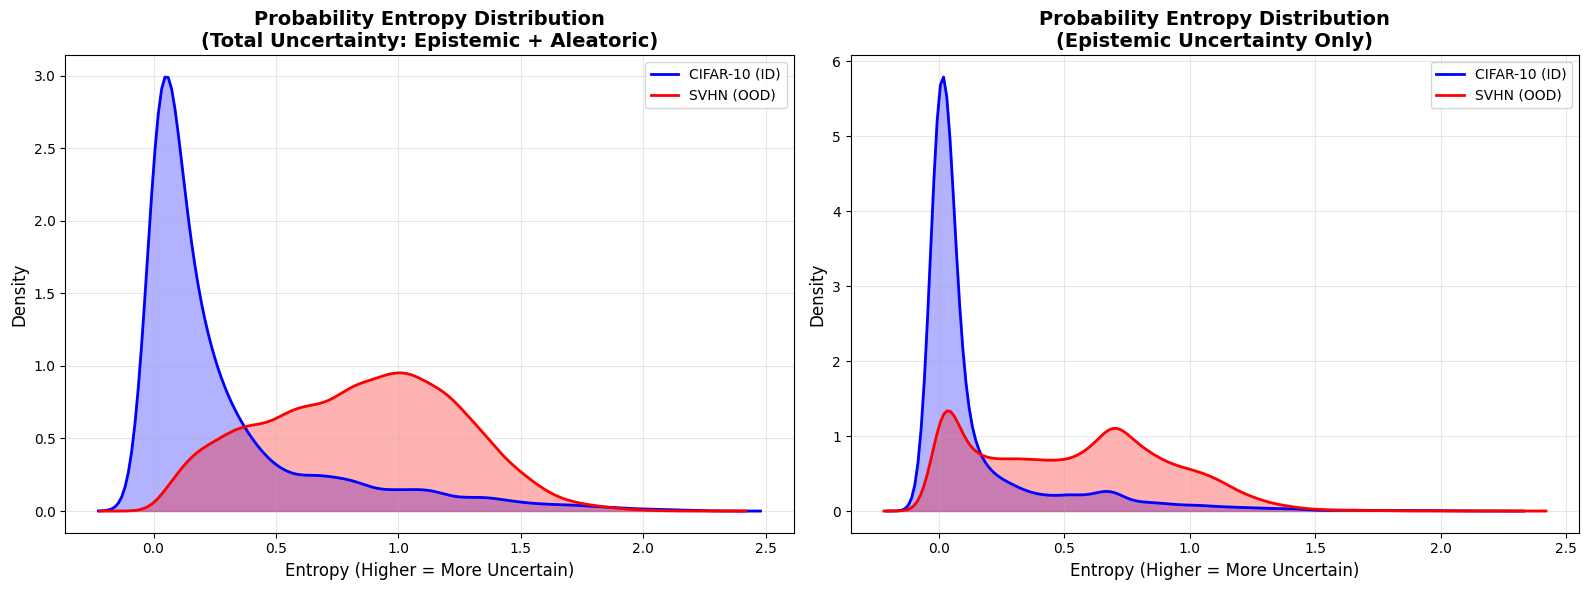


Entropy Statistics:
CIFAR-10 (Total): Mean=0.2839, Std=0.3816
SVHN (Total):     Mean=0.8483, Std=0.3899
CIFAR-10 (Epist): Mean=0.1475, Std=0.2811
SVHN (Epist):     Mean=0.5353, Std=0.3729


In [22]:
# Plot entropy distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total Variance
ax1 = axes[0]
plot_kde(ax1, cifar_ood_total['entropy'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax1, svhn_ood_total['entropy'], 'red', 'SVHN (OOD)')
ax1.set_title('Probability Entropy Distribution\n(Total Uncertainty: Epistemic + Aleatoric)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Entropy (Higher = More Uncertain)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Epistemic Only
ax2 = axes[1]
plot_kde(ax2, cifar_ood_epistemic['entropy'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax2, svhn_ood_epistemic['entropy'], 'red', 'SVHN (OOD)')
ax2.set_title('Probability Entropy Distribution\n(Epistemic Uncertainty Only)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Entropy (Higher = More Uncertain)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEntropy Statistics:")
print(f"CIFAR-10 (Total): Mean={np.mean(cifar_ood_total['entropy']):.4f}, "
      f"Std={np.std(cifar_ood_total['entropy']):.4f}")
print(f"SVHN (Total):     Mean={np.mean(svhn_ood_total['entropy']):.4f}, "
      f"Std={np.std(svhn_ood_total['entropy']):.4f}")
print(f"CIFAR-10 (Epist): Mean={np.mean(cifar_ood_epistemic['entropy']):.4f}, "
      f"Std={np.std(cifar_ood_epistemic['entropy']):.4f}")
print(f"SVHN (Epist):     Mean={np.mean(svhn_ood_epistemic['entropy']):.4f}, "
      f"Std={np.std(svhn_ood_epistemic['entropy']):.4f}")

### Variance Distribution Plots

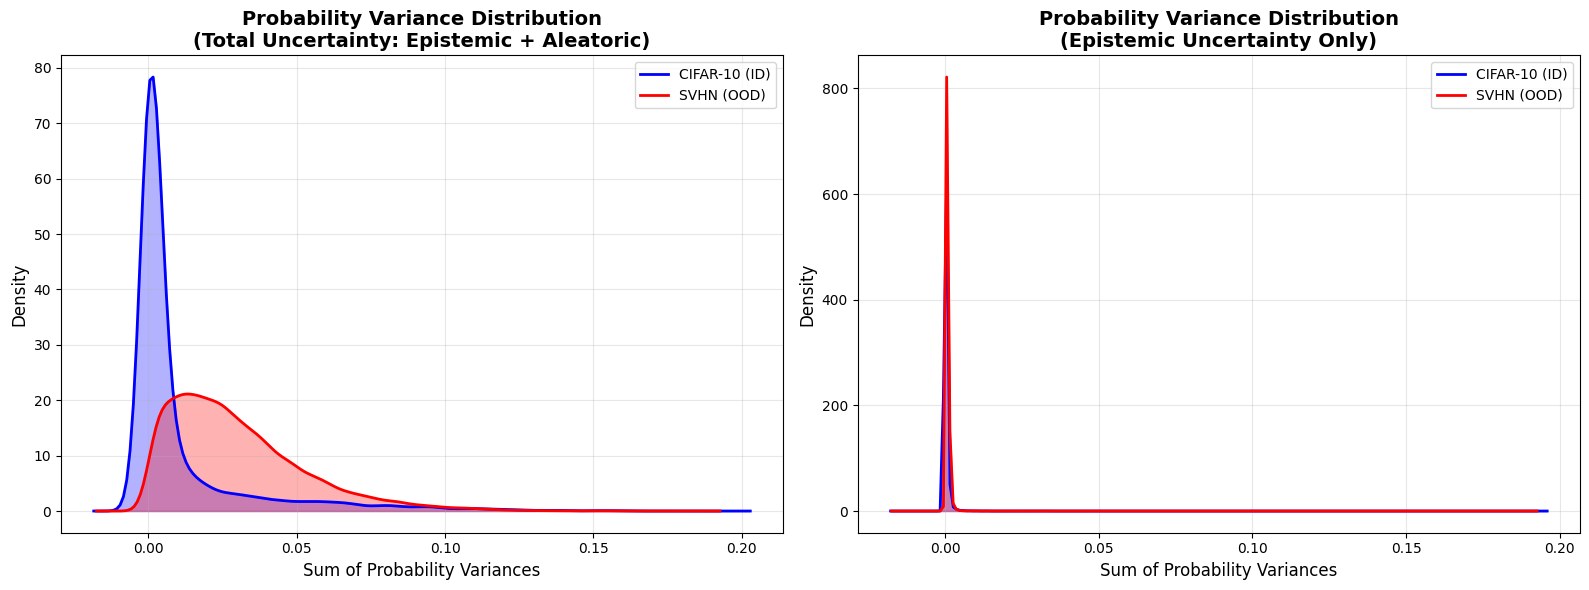

In [23]:
# Plot variance distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Total Variance
ax1 = axes[0]
plot_kde(ax1, cifar_ood_total['variance'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax1, svhn_ood_total['variance'], 'red', 'SVHN (OOD)')
ax1.set_title('Probability Variance Distribution\n(Total Uncertainty: Epistemic + Aleatoric)', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Sum of Probability Variances', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Epistemic Only
ax2 = axes[1]
plot_kde(ax2, cifar_ood_epistemic['variance'], 'blue', 'CIFAR-10 (ID)')
plot_kde(ax2, svhn_ood_epistemic['variance'], 'red', 'SVHN (OOD)')
ax2.set_title('Probability Variance Distribution\n(Epistemic Uncertainty Only)', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Sum of Probability Variances', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Rejection Curves

Evaluating model performance under selective prediction (rejecting uncertain samples).

### Rejection Curves with Total Uncertainty

=== Rejection Curves with TOTAL Uncertainty (Epistemic + Aleatoric) ===
Rejection curves saved to rejection_curves_total.png


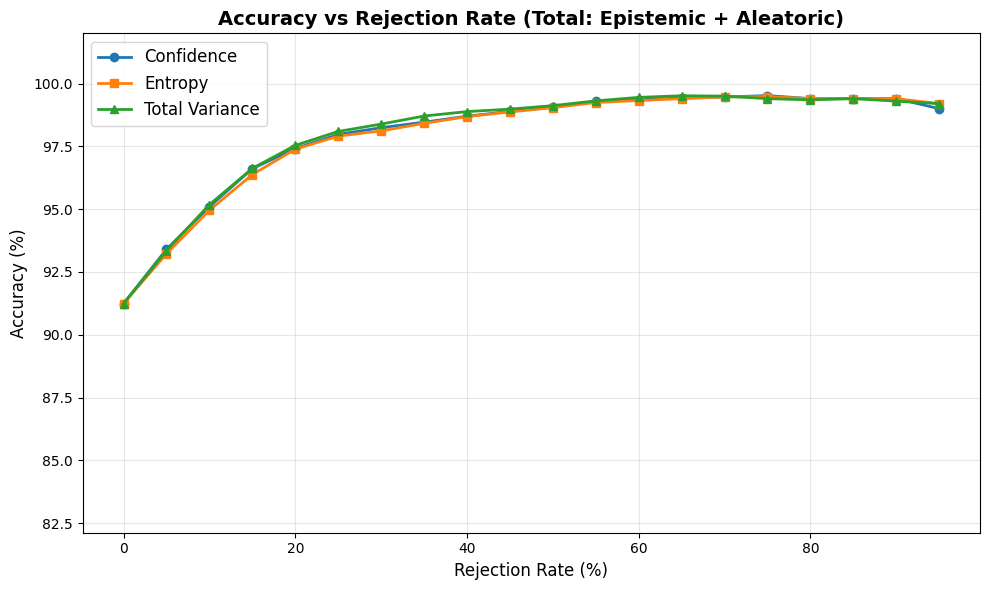

In [24]:
print("=== Rejection Curves with TOTAL Uncertainty (Epistemic + Aleatoric) ===")
plot_rejection_curves(
    probs_total, 
    var_probs_total, 
    predictions_total, 
    labels_clean,
    title_suffix=' (Total: Epistemic + Aleatoric)',
    save_path='rejection_curves_total.png'
)

### Rejection Curves with Epistemic Uncertainty Only

=== Rejection Curves with EPISTEMIC Uncertainty Only ===
Rejection curves saved to rejection_curves_epistemic.png


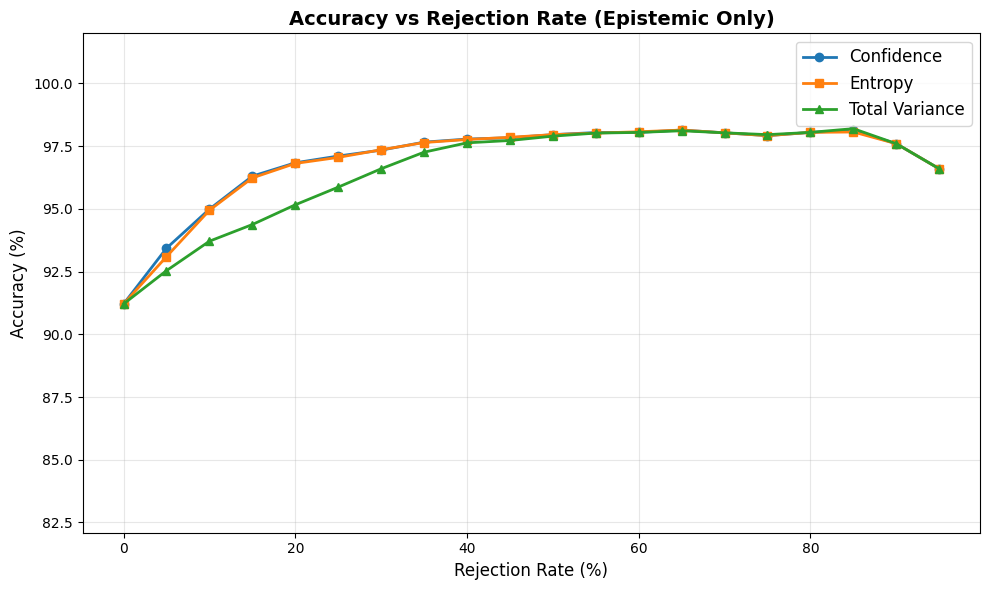

In [25]:
print("=== Rejection Curves with EPISTEMIC Uncertainty Only ===")
plot_rejection_curves(
    probs_epistemic, 
    var_probs_epistemic, 
    predictions_epistemic, 
    labels_clean,
    title_suffix=' (Epistemic Only)',
    save_path='rejection_curves_epistemic.png'
)